In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def weekday_word(weekday):
    if weekday==0:
        return "Monday"
    elif weekday==1:
        return "Tuesday"
    elif weekday==2:
        return "Wednesday"
    elif weekday==3:
        return "Thursday"
    elif weekday==4:
        return "Friday"
    elif weekday==5:
        return "Saturday"
    else:
        return "Sunday"
    
def is_weekend(weekday):
    return weekday in [5,6]

### Feature forklaring
- User Type: 
    - Customer = 24-hour pass or 3-day pass
    - Subscriber = Annual Member
- Gender:
    - 0 -> Unknown
    - 1 -> Male
    - 2 -> Female

In [3]:
f=pd.read_csv("Trips_2018.csv")

In [4]:
f.describe()

,Unnamed: 0,tripduration,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,birth_year,gender
count,1.754834e+07,1.754834e+07,1.754584e+07,1.754834e+07,1.754834e+07,1.754584e+07,1.754834e+07,1.754834e+07,1.754834e+07,1.754834e+07,1.754834e+07
mean,8.774169e+06,9.887432e+02,1.589282e+03,4.073737e+01,-7.398260e+01,1.580830e+03,4.073704e+01,-7.398281e+01,2.656141e+04,1.978993e+03,1.148613e+00
std,5.065769e+06,1.889584e+04,1.439432e+03,3.225813e-02,1.912753e-02,1.438502e+03,3.206583e-02,1.919611e-02,6.222916e+03,1.192922e+01,5.438043e-01
min,0.000000e+00,6.100000e+01,7.200000e+01,4.064654e+01,-7.402535e+01,7.200000e+01,4.064654e+01,-7.408364e+01,1.452900e+04,1.885000e+03,0.000000e+00
25%,4.387084e+06,3.580000e+02,3.800000e+02,4.071755e+01,-7.399521e+01,3.800000e+02,4.071755e+01,-7.399595e+01,2.029300e+04,1.969000e+03,1.000000e+00
50%,8.774169e+06,6.050000e+02,5.050000e+02,4.073818e+01,-7.398565e+01,5.050000e+02,4.073756e+01,-7.398602e+01,2.827000e+04,1.981000e+03,1.000000e+00
75%,1.316125e+07,1.060000e+03,3.249000e+03,4.075763e+01,-7.397283e+01,3.249000e+03,4.075725e+01,-7.397344e+01,3.185200e+04,1.989000e+03,1.000000e+00
max,1.754834e+07,1.951005e+07,3.721000e+03,4.550636e+01,-7.356891e+01,3.721000e+03,4.550636e+01,-7.356891e+01,3.583100e+04,2.002000e+03,2.000000e+00


In [5]:
f = f.rename({"Unnamed: 0": "Trip ID"}, axis="columns")
f = f.set_index("Trip ID")

In [6]:
f.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender
Trip ID,,,,,,,,,,,,,
0,970,2018-01-01 13:50:57.4340,2018-01-01 14:07:08.1860,72.0,40.767272,-73.993929,505.0,40.749013,-73.988484,31956,Subscriber,1992,1
1,723,2018-01-01 15:33:30.1820,2018-01-01 15:45:33.3410,72.0,40.767272,-73.993929,3255.0,40.750585,-73.994685,32536,Subscriber,1969,1
2,496,2018-01-01 15:39:18.3370,2018-01-01 15:47:35.1720,72.0,40.767272,-73.993929,525.0,40.755942,-74.002116,16069,Subscriber,1956,1
3,306,2018-01-01 15:40:13.3720,2018-01-01 15:45:20.1910,72.0,40.767272,-73.993929,447.0,40.763707,-73.985162,31781,Subscriber,1974,1
4,306,2018-01-01 18:14:51.5680,2018-01-01 18:19:57.6420,72.0,40.767272,-73.993929,3356.0,40.774667,-73.984706,30319,Subscriber,1992,1


In [7]:
f['starttime'] = pd.to_datetime(f['starttime'], format='%Y-%m-%d %H:%M:%S.%f')
f['stoptime'] = pd.to_datetime(f['stoptime'], format='%Y-%m-%d %H:%M:%S.%f')
f['weekday']= f['starttime'].dt.weekday
f['is_weekend']=[is_weekend(el) for el in f['weekday']]
# sm_dummies=pd.get_dummies(f, columns=['usertype'])
# sm_dummies.head()

In [8]:
f.dtypes

tripduration                        int64
starttime                  datetime64[ns]
stoptime                   datetime64[ns]
start_station_id                  float64
start_station_latitude            float64
start_station_longitude           float64
end_station_id                    float64
end_station_latitude              float64
end_station_longitude             float64
bikeid                              int64
usertype                           object
birth_year                          int64
gender                              int64
weekday                             int32
is_weekend                           bool
dtype: object

In [9]:
# sm_dummies.dtypes

# Looking at coordinates

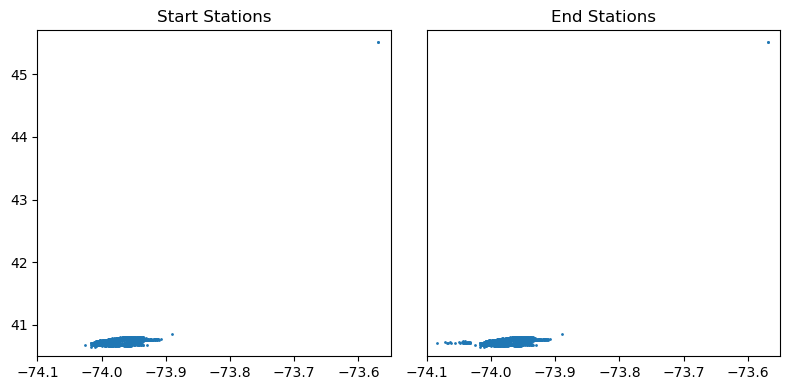

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.55), (40.5, 45.7)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

# Remove outlier

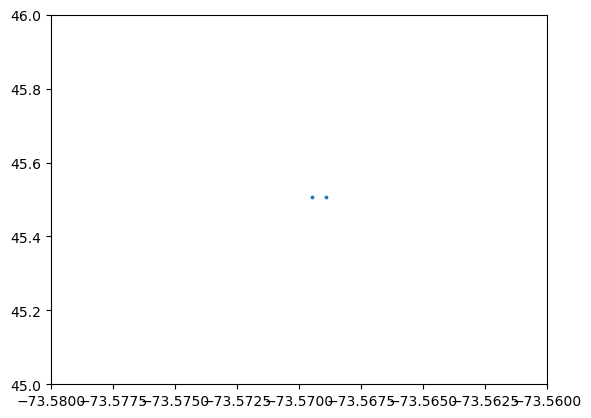

In [11]:
plt.scatter(start_station_df['longitude'], start_station_df['latitude'], s=3)
plt.xlim((-73.58, -73.56))
plt.ylim((45, 46))
plt.show()

In [12]:
start_station_df[start_station_df.longitude > -73.6]

,latitude,longitude
start_station_id,,
3488.0,45.506364,-73.569463
3650.0,45.506264,-73.568906


In [13]:
end_station_df[end_station_df.longitude > -73.6]

,latitude,longitude
end_station_id,,
3488.0,45.506364,-73.569463
3650.0,45.506264,-73.568906


In [14]:
f[
    (f.start_station_id == 3488.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [15]:
f[
    (f.end_station_id == 3488.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,
8772457,1634200,2018-07-18 18:27:51.511,2018-08-06 16:24:32.388,3036.0,40.662908,-73.999722,3488.0,45.506364,-73.569463,24354,Subscriber,1988,1,2,False


In [16]:
f[
    (f.start_station_id == 3650.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [17]:
f[
    (f.end_station_id == 3650.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [18]:
f[
    (f.start_station_id == 3488) | (f.end_station_id == 3488) |
    (f.start_station_id == 3650) | (f.end_station_id == 3650)
].describe()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,birth_year,gender,weekday
count,8.200000e+01,82,82,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,2.954804e+04,2018-03-14 21:46:53.854036736,2018-03-15 05:59:22.416878080,3636.585366,45.447203,-73.574180,3642.097561,45.506269,-73.568933,23651.158537,1985.792683,1.012195,1.378049
min,6.200000e+01,2018-01-08 16:03:59.375000,2018-01-08 16:09:41.338000,3036.000000,40.662908,-73.999722,3488.000000,45.506264,-73.569463,17667.000000,1969.000000,0.000000,0.000000
25%,2.235000e+02,2018-01-26 10:59:14.185999872,2018-01-26 12:46:01.522750208,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,21928.000000,1986.000000,1.000000,0.000000
50%,9.390000e+02,2018-02-20 14:11:07.361499904,2018-02-20 14:12:41.880000,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,24354.000000,1986.000000,1.000000,1.000000
75%,2.653500e+03,2018-05-08 17:10:19.270750208,2018-05-08 17:19:55.421250048,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,24354.000000,1986.000000,1.000000,3.000000
max,1.634200e+06,2018-07-18 18:27:51.511000,2018-08-06 16:24:32.388000,3650.000000,45.506364,-73.568906,3650.000000,45.506364,-73.568906,24354.000000,1988.000000,2.000000,4.000000
std,1.827257e+05,NaN,NaN,73.784128,0.534860,0.047574,35.110974,0.000022,0.000121,1256.116408,2.752049,0.248149,1.329998


We have two outliers stations with id 3448 and 3650. We found that they are both placed right next to one another in Montreal, Canada. From the above cells, it is apparent that all but one trips completed with start or end point in Montreal (station 3488 and 3650) are trips in Montreal only.

There is a single trip from Brooklyn (station 3036) to Montreal (station 3488). It's duration is 18.9 days and out of 17 million trips completed, this one is the only one travelling to Montreal. Therefore we classify stations in Montreal as not relevant and outliers.

In [19]:
f = f.drop(
    f[
        (f.start_station_id == 3488) | (f.end_station_id == 3488) |
        (f.start_station_id == 3650) | (f.end_station_id == 3650)
    ].index
)

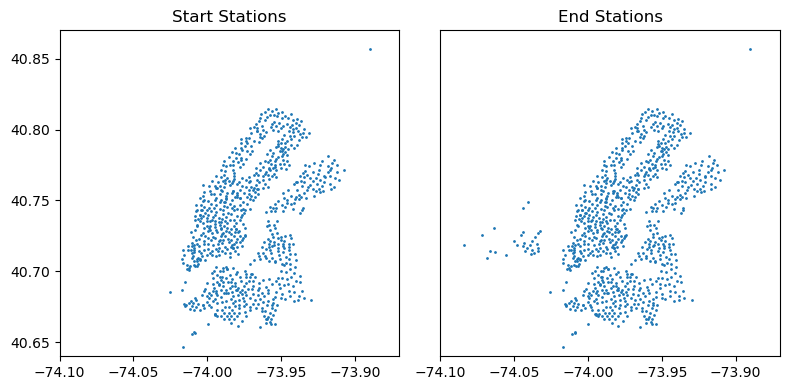

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.87), (40.64, 40.87)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

### Classifying the stations with ID: NaN

We find that a great deal of stations have ID = NaN. So we try and plot them to find their location.

In [21]:
start_ids = np.unique(f.start_station_id)
end_ids = np.unique(f.end_station_id)
print(f"Number of NaN values in start_station_id: {f.start_station_id.isna().sum()}")
print(f"Number of NaN values in end_station_id: {f.end_station_id.isna().sum()}")
start_station_df[start_station_df.index.isna()]

Number of NaN values in start_station_id: 2497
Number of NaN values in end_station_id: 2497


,latitude,longitude
start_station_id,,
NaN,40.857,-73.89


2497 trips have a station ID with NaN-value

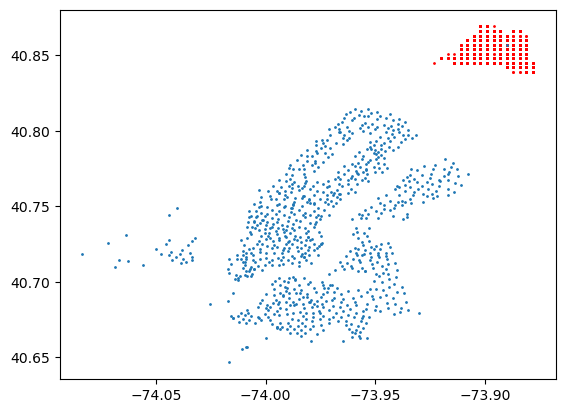

In [22]:
f_nan = f[f.start_station_id.isna()][['start_station_longitude', 'start_station_latitude']]
plt.scatter(f_nan.start_station_longitude, f_nan.start_station_latitude, s=1, c='r', label="NaN-station")
plt.scatter(end_station_df['longitude'], end_station_df['latitude'], s=1)
plt.show()

In [23]:
print("\nCheck: Are the placements different? If all 0, then all placements same")
print(np.unique(f[f.start_station_id.isna()].start_station_longitude) - np.unique(f[f.start_station_id.isna()].end_station_longitude))
print(np.unique(f[f.end_station_id.isna()].start_station_longitude) - np.unique(f[f.end_station_id.isna()].end_station_longitude))
print(np.unique(f[f.start_station_id.isna()].start_station_latitude) - np.unique(f[f.start_station_id.isna()].end_station_latitude))
print(np.unique(f[f.end_station_id.isna()].start_station_latitude) - np.unique(f[f.end_station_id.isna()].end_station_latitude))

print("\nValues for longitude and latitude")
print(np.unique(f[f.start_station_id.isna()].start_station_longitude))
print(np.unique(f[f.start_station_id.isna()].start_station_latitude))

print(f"\nNumber of stations with NaN-value as ID: {len(np.unique(f[f.start_station_id.isna()].start_station_longitude))}")


Check: Are the placements different? If all 0, then all placements same
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Values for longitude and latitude
[-73.923 -73.92  -73.917 -73.914 -73.911 -73.908 -73.905 -73.902 -73.899
 -73.896 -73.893 -73.89  -73.887 -73.884 -73.881 -73.878]
[40.839 40.842 40.845 40.848 40.851 40.854 40.857 40.86  40.863 40.866
 40.869]

Number of stations with NaN-value as ID: 16


Okay, all 16 NaN-ID-stations are located in a single 'cluster' or grouping.
Looking at the placement in a map, the red grouping lies in the Bronx area North of New York. Also as a result of our plotting the single blue dot is the result of dropping duplicates on the ID's. This means that it, in previous plots, represented all the red dots, we now found.

We check whether or not we have data on any trips leaving this grouping. 

In [24]:
f[(f.start_station_id.isna()) & (f.end_station_id.notna())]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [25]:
f[(f.start_station_id.notna()) & (f.end_station_id.isna())]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


Okay, no trips from a NaN-ID-station leaves the grouping in the Bronx area. Hence, they have no implication on clusters in the central New York area. Since that is the case they wont be important for rebalancing the bike locations, so we classicy them as outliers

In [26]:
f = f.dropna()

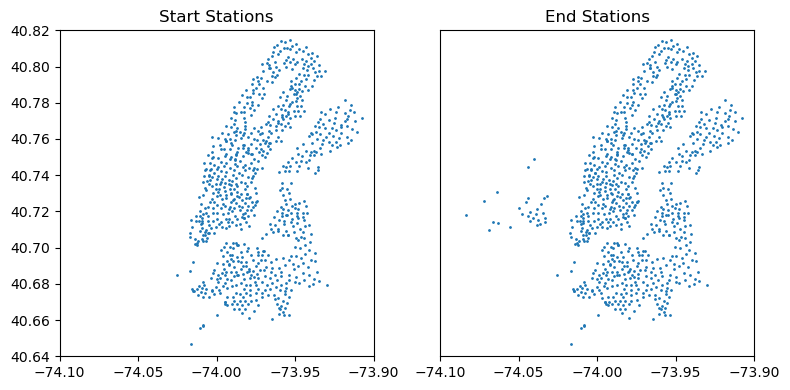

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.9), (40.64, 40.82)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

## K-means

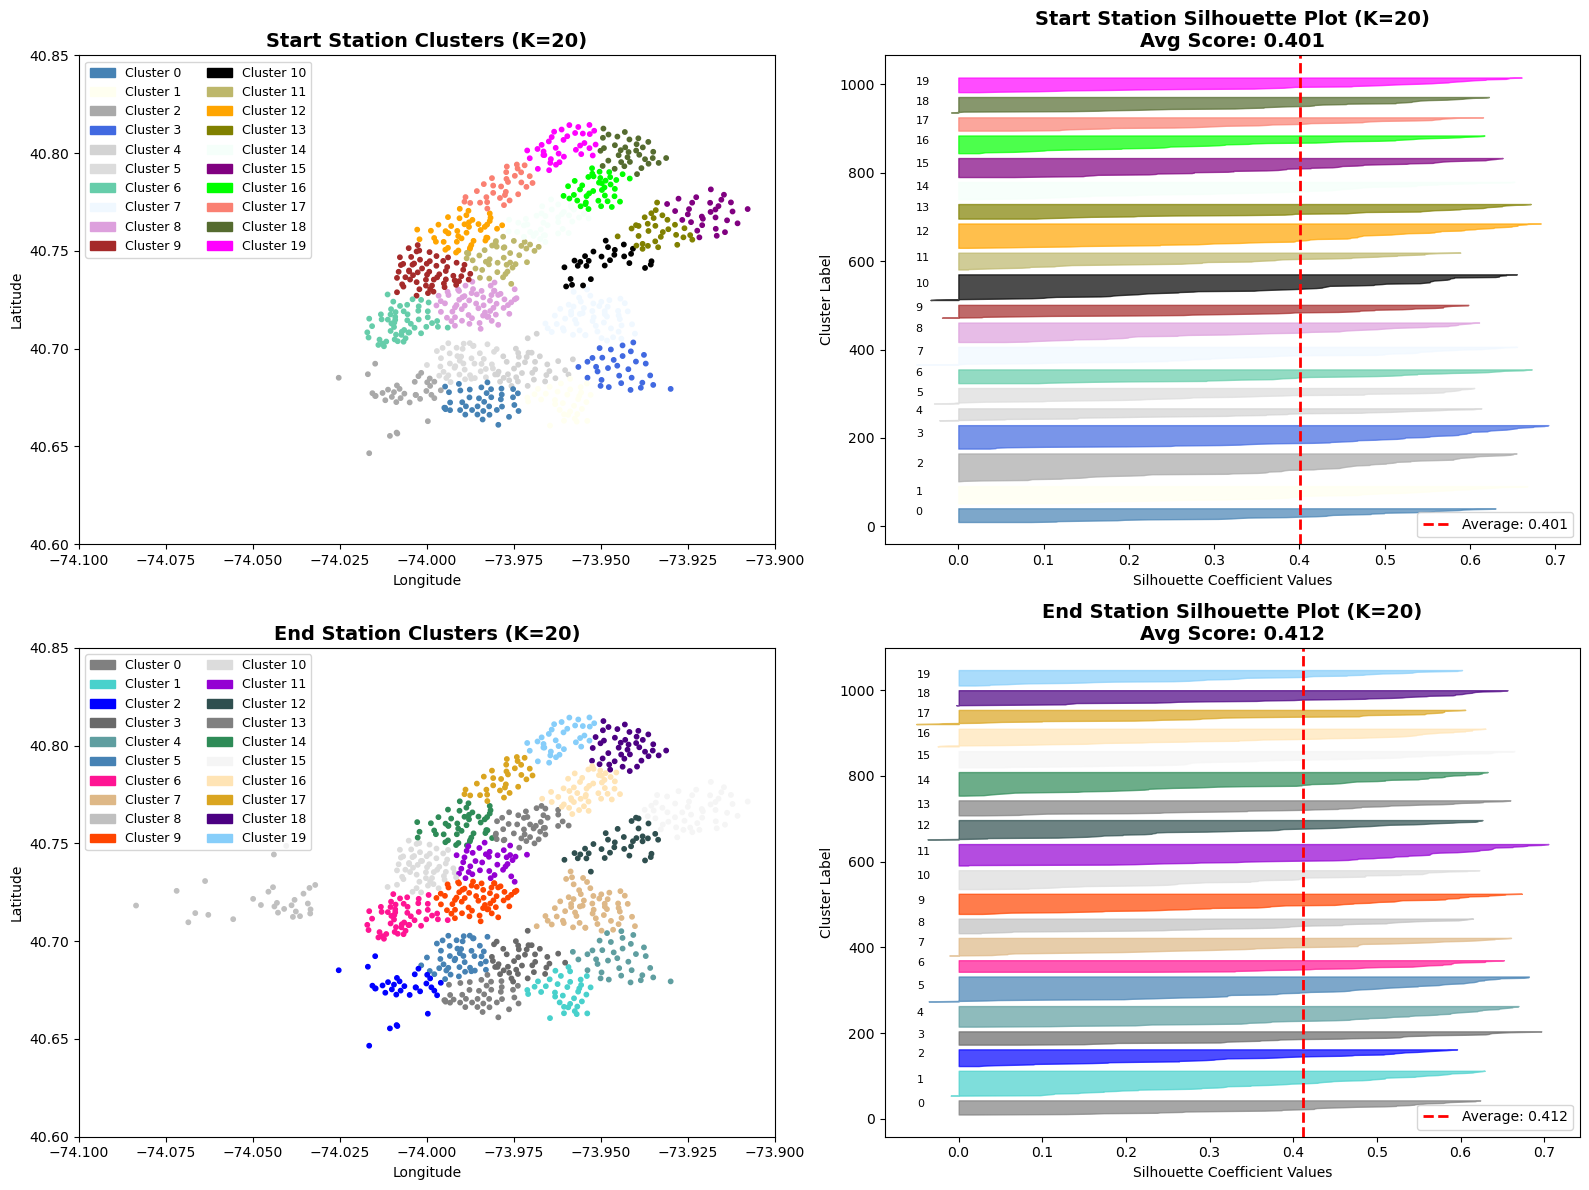

Start Station Average Silhouette Score: 0.401
End Station Average Silhouette Score: 0.412


In [28]:
from sklearn.cluster import KMeans
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import random

K=20

# Fit K-means for start stations
k_start=KMeans(K, random_state=42, n_init=30)
k_end=KMeans(K, random_state=42, n_init=30)

k_start.fit(start_station_df)
k_end.fit(end_station_df)
centroids_start = k_start.cluster_centers_
centroids_end = k_end.cluster_centers_

# Fixing labelling start
order = np.argsort(centroids_start[:, 0])
mapping = {old: new for new, old in enumerate(order)}
fix_labels_start = np.array([mapping[label] for label in k_start.labels_])

# Fixing labelling end
order = np.argsort(centroids_end[:, 0])
mapping = {old: new for new, old in enumerate(order)}
fix_labels_end = np.array([mapping[label] for label in k_end.labels_])

dt_clusters_start=start_station_df.copy()
dt_clusters_start['cluster']= fix_labels_start

dt_clusters_end=end_station_df.copy()
dt_clusters_end['cluster']=fix_labels_end

# Generate colors
num_colors=K
colors=list(mcolors.CSS4_COLORS.keys())
cluster_colors_start = random.choices(colors,k=K)
cluster_colors_end = random.choices(colors,k=K)

# Prepare data for start stations
x_points_start=dt_clusters_start["longitude"]
y_points_start=dt_clusters_start["latitude"]
labels_start = dt_clusters_start["cluster"]
x_start=[]
y_start=[]
c_start=[]
for label, x, y in zip(labels_start, x_points_start, y_points_start):
    if label == -1:
        continue
    x_start.append(x)
    y_start.append(y)
    c_start.append(cluster_colors_start[label])

# Prepare data for end stations
x_points_end=dt_clusters_end["longitude"]
y_points_end=dt_clusters_end["latitude"]
labels_end = dt_clusters_end["cluster"]
x_end=[]
y_end=[]
c_end=[]
for label, x, y in zip(labels_end, x_points_end, y_points_end):
    if label==-1:
        continue
    x_end.append(x)
    y_end.append(y)
    c_end.append(cluster_colors_end[label])

# Calculate silhouette scores
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

silhouette_avg_start = silhouette_score(start_station_df, k_start.labels_)
sample_silhouette_values_start = silhouette_samples(start_station_df, k_start.labels_)

silhouette_avg_end = silhouette_score(end_station_df, k_end.labels_)
sample_silhouette_values_end = silhouette_samples(end_station_df, k_end.labels_)

# Create combined plot with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Start Station Clusters
ax1 = axes[0, 0]
ax1.scatter(x_start, y_start, s=10, c=c_start)
ax1.set_xlim(-74.1, -73.9)
ax1.set_ylim(40.6, 40.85)
ax1.set_title(f'Start Station Clusters (K={K})', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
legend_patches_start = [Patch(color=cluster_colors_start[i], label=f"Cluster {i}") for i in range(K)]
ax1.legend(handles=legend_patches_start, loc='upper left', fontsize=9, ncol=2)

# Plot 2: Start Station Silhouette Plot
ax2 = axes[0, 1]
y_lower = 10
for i in range(K):
    ith_cluster_silhouette_values = sample_silhouette_values_start[k_start.labels_ == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cluster_colors_start[i]
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=8)
    y_lower = y_upper + 10
ax2.set_title(f"Start Station Silhouette Plot (K={K})\nAvg Score: {silhouette_avg_start:.3f}", 
              fontsize=14, fontweight='bold')
ax2.set_xlabel("Silhouette Coefficient Values")
ax2.set_ylabel("Cluster Label")
ax2.axvline(x=silhouette_avg_start, color="red", linestyle="--", linewidth=2, 
            label=f"Average: {silhouette_avg_start:.3f}")
ax2.legend()

# Plot 3: End Station Clusters
ax3 = axes[1, 0]
ax3.scatter(x_end, y_end, s=10, c=c_end)
ax3.set_xlim(-74.1, -73.9)
ax3.set_ylim(40.6, 40.85)
ax3.set_title(f'End Station Clusters (K={K})', fontsize=14, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
legend_patches_end = [Patch(color=cluster_colors_end[i], label=f"Cluster {i}") for i in range(K)]
ax3.legend(handles=legend_patches_end, loc='upper left', fontsize=9, ncol=2)

# Plot 4: End Station Silhouette Plot
ax4 = axes[1, 1]
y_lower = 10
for i in range(K):
    ith_cluster_silhouette_values = sample_silhouette_values_end[k_end.labels_ == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cluster_colors_end[i]
    ax4.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax4.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=8)
    y_lower = y_upper + 10
ax4.set_title(f"End Station Silhouette Plot (K={K})\nAvg Score: {silhouette_avg_end:.3f}", 
              fontsize=14, fontweight='bold')
ax4.set_xlabel("Silhouette Coefficient Values")
ax4.set_ylabel("Cluster Label")
ax4.axvline(x=silhouette_avg_end, color="red", linestyle="--", linewidth=2, 
            label=f"Average: {silhouette_avg_end:.3f}")
ax4.legend()

plt.tight_layout()
plt.show()

print(f"Start Station Average Silhouette Score: {silhouette_avg_start:.3f}")
print(f"End Station Average Silhouette Score: {silhouette_avg_end:.3f}")

In [ ]:
plt.
ax1 = axes[0, 0]
ax1.scatter(x_start, y_start, s=10, c=c_start)
ax1.set_xlim(-74.1, -73.9)
ax1.set_ylim(40.6, 40.85)
ax1.set_title(f'Start Station Clusters (K={K})', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
legend_patches_start = [Patch(color=cluster_colors_start[i], label=f"Cluster {i}") for i in range(K)]
ax1.legend(handles=legend_patches_start, loc='upper left', fontsize=9, ncol=2)

# Load a fixed labelling from file

In [29]:
# np.savetxt('fix_labels_start.txt', fix_labels_start) # for updating the fixed cluster labelling used

fixed_cluster_labels = np.loadtxt('fix_labels_start.txt')
dt_clusters_all = dt_clusters_start.copy() # All stations are represented in start_station_id column
dt_clusters_all['cluster'] = fixed_cluster_labels

# Connect clusters with the 17 mio data frame

In [30]:
df_merged_start = f.merge(
    dt_clusters_all['cluster'], 
    left_on='start_station_id', 
    right_index=True, 
    how='left'
)

df_merged_end = f.merge(
    dt_clusters_all['cluster'], 
    left_on='end_station_id', 
    right_index=True, 
    how='left'
)

In [31]:
np.unique(dt_clusters_all[dt_clusters_all.cluster == 12].index)

array([  72.,  173.,  267.,  362.,  379.,  422.,  423.,  447.,  448.,
        449.,  450.,  457.,  465.,  468.,  469.,  477.,  478.,  479.,
        480.,  490.,  492.,  493.,  495.,  499.,  500.,  508.,  513.,
        514.,  515.,  523.,  524.,  525.,  529.,  530.,  533., 2021.,
       3236., 3240., 3255., 3443., 3458., 3466., 3635., 3699., 3712.])

# Investigating a cluster

In [32]:
cluster_12_departures = df_merged_start[df_merged_start["cluster"] == 12].copy()
cluster_12_arrivals = df_merged_end[df_merged_end['cluster'] == 12].copy()
cluster_12_departures.size, cluster_12_arrivals.size

(32407136, 32485504)

In [33]:
cluster_12_departures.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend,cluster
Trip ID,,,,,,,,,,,,,,,,
0,970,2018-01-01 13:50:57.434,2018-01-01 14:07:08.186,72.0,40.767272,-73.993929,505.0,40.749013,-73.988484,31956,Subscriber,1992,1,0,False,12.0
1,723,2018-01-01 15:33:30.182,2018-01-01 15:45:33.341,72.0,40.767272,-73.993929,3255.0,40.750585,-73.994685,32536,Subscriber,1969,1,0,False,12.0
2,496,2018-01-01 15:39:18.337,2018-01-01 15:47:35.172,72.0,40.767272,-73.993929,525.0,40.755942,-74.002116,16069,Subscriber,1956,1,0,False,12.0
3,306,2018-01-01 15:40:13.372,2018-01-01 15:45:20.191,72.0,40.767272,-73.993929,447.0,40.763707,-73.985162,31781,Subscriber,1974,1,0,False,12.0
4,306,2018-01-01 18:14:51.568,2018-01-01 18:19:57.642,72.0,40.767272,-73.993929,3356.0,40.774667,-73.984706,30319,Subscriber,1992,1,0,False,12.0


# Data visualization for a cluster

In [34]:
# Make sure starttime is a datetime
cluster_12_departures['starttime'] = pd.to_datetime(cluster_12_departures['starttime'])

# Extract date and hour
cluster_12_departures['date'] = cluster_12_departures['starttime'].dt.date
cluster_12_departures['hour'] = cluster_12_departures['starttime'].dt.hour

# Group by date and hour, count trips
trips_per_hour = cluster_12_departures.groupby(['date', 'hour']).size().reset_index(name='num_trips')
trips_per_hour[:25]


,date,hour,num_trips
0,2018-01-01,0,14
1,2018-01-01,1,15
2,2018-01-01,2,7
3,2018-01-01,3,8
4,2018-01-01,4,6
5,2018-01-01,5,2
6,2018-01-01,6,6
7,2018-01-01,7,7
8,2018-01-01,8,10
9,2018-01-01,9,7


In [35]:

trips_per_hour['datetime'] = pd.to_datetime(trips_per_hour['date'].astype(str)) + pd.to_timedelta(trips_per_hour['hour'], unit='h')
trips_per_hour.set_index('datetime', inplace=True)
trips_per_hour.drop(columns=['date'], inplace=True)
trips_per_hour.head()

,hour,num_trips
datetime,,
2018-01-01 00:00:00,0,14
2018-01-01 01:00:00,1,15
2018-01-01 02:00:00,2,7
2018-01-01 03:00:00,3,8
2018-01-01 04:00:00,4,6


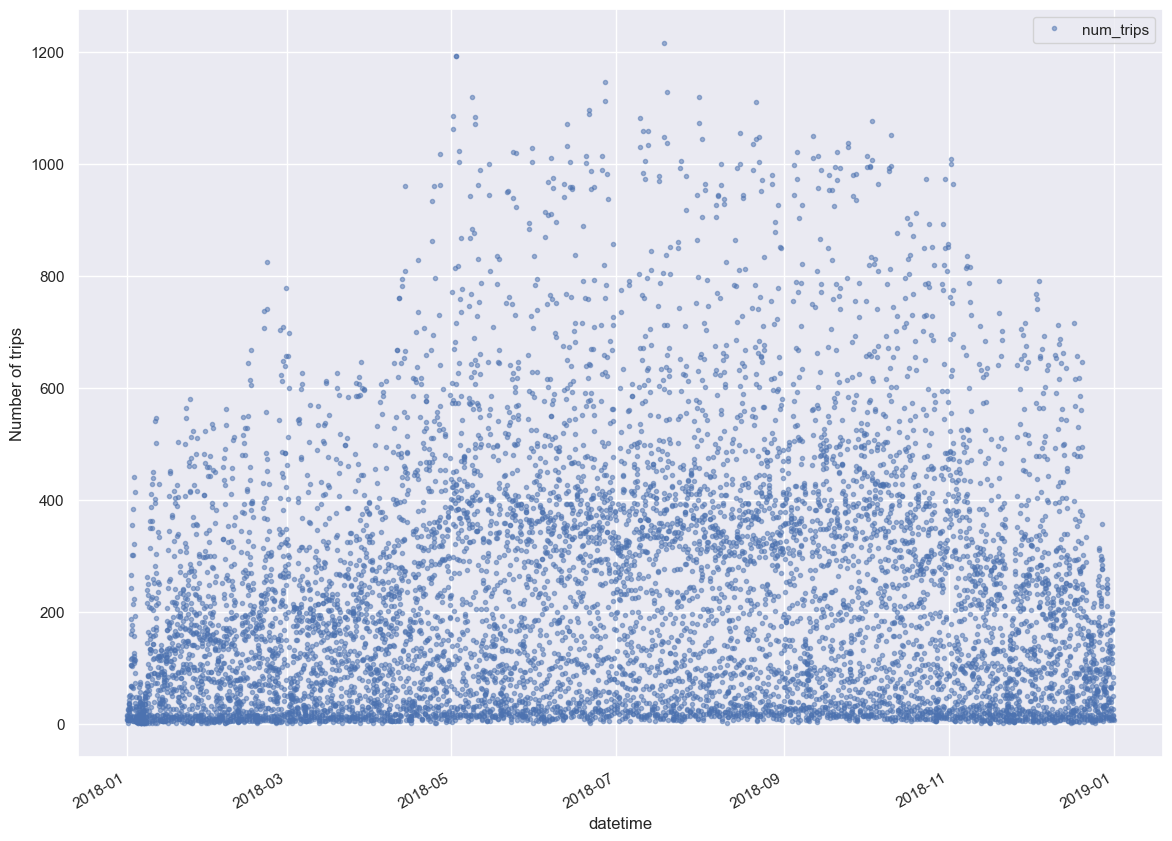

In [36]:
import seaborn as sns
sns.set_theme(rc={'figure.figsize':(14, 5)})
cols_plot = ['num_trips']
axes = trips_per_hour[cols_plot].plot(marker='.', alpha=0.5, linestyle='None', figsize=(14, 11), subplots=True)
axes[0].set_ylabel('Number of trips')
plt.show()

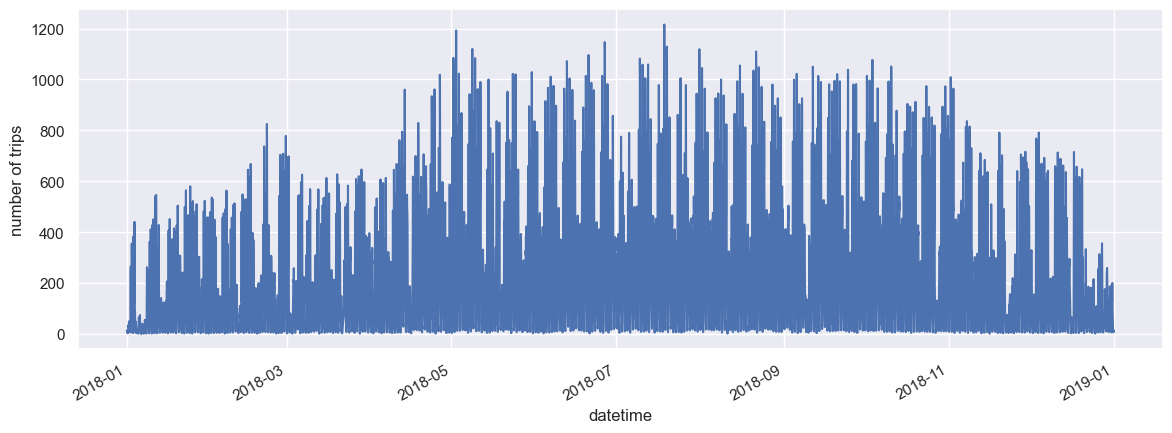

In [37]:
ax = trips_per_hour.loc['2018', 'num_trips'].plot()
ax.set_ylabel('number of trips')
plt.show()

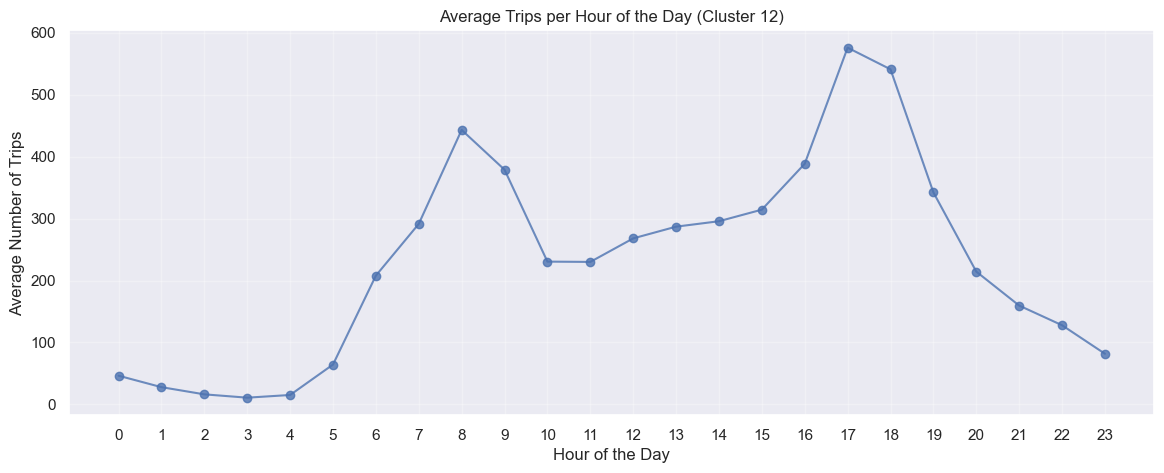

In [38]:
# Average trips per hour (0-23) across all days
avg_trips_by_hour = trips_per_hour.groupby('hour')['num_trips'].mean()
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(rc={'figure.figsize':(14, 5)})

# Plot average trips by hour
avg_trips_by_hour.plot(marker='o', linestyle='-', alpha=0.8)

plt.xlabel('Hour of the Day')
plt.ylabel('Average Number of Trips')
plt.title('Average Trips per Hour of the Day (Cluster 12)')
plt.xticks(range(0,24))  # ensure all hours are labeled
plt.grid(True, alpha=0.3)
plt.show()


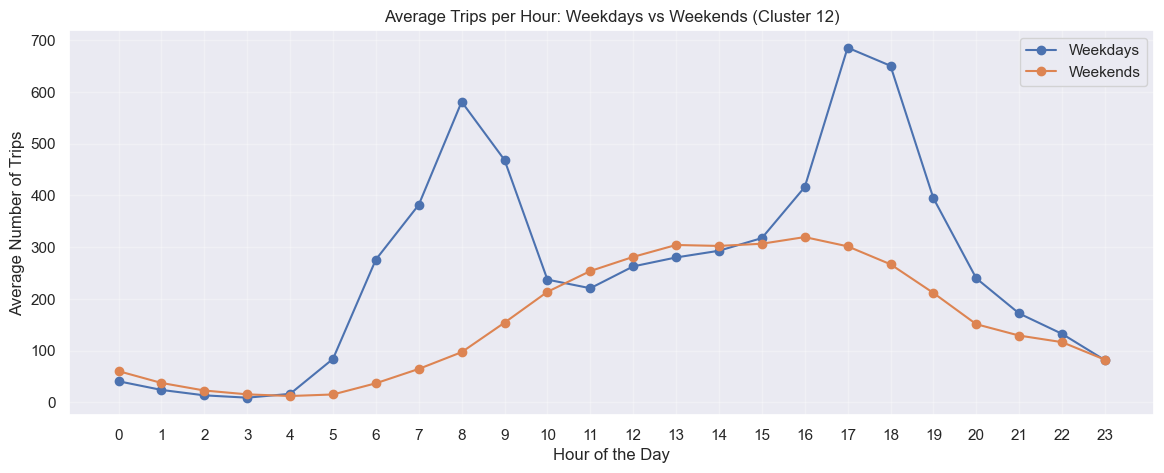

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract hour from datetime index if not already present
trips_per_hour['hour'] = trips_per_hour.index.hour
trips_per_hour['is_weekend'] = trips_per_hour.index.weekday >= 5

# Average trips per hour for weekdays
avg_weekday = trips_per_hour[~trips_per_hour['is_weekend']].groupby('hour')['num_trips'].mean()

# Average trips per hour for weekends
avg_weekend = trips_per_hour[trips_per_hour['is_weekend']].groupby('hour')['num_trips'].mean()

# Plot
sns.set(rc={'figure.figsize':(14,5)})
plt.plot(avg_weekday.index, avg_weekday.values, marker='o', linestyle='-', label='Weekdays')
plt.plot(avg_weekend.index, avg_weekend.values, marker='o', linestyle='-', label='Weekends')

plt.xlabel('Hour of the Day')
plt.ylabel('Average Number of Trips')
plt.title('Average Trips per Hour: Weekdays vs Weekends (Cluster 12)')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()


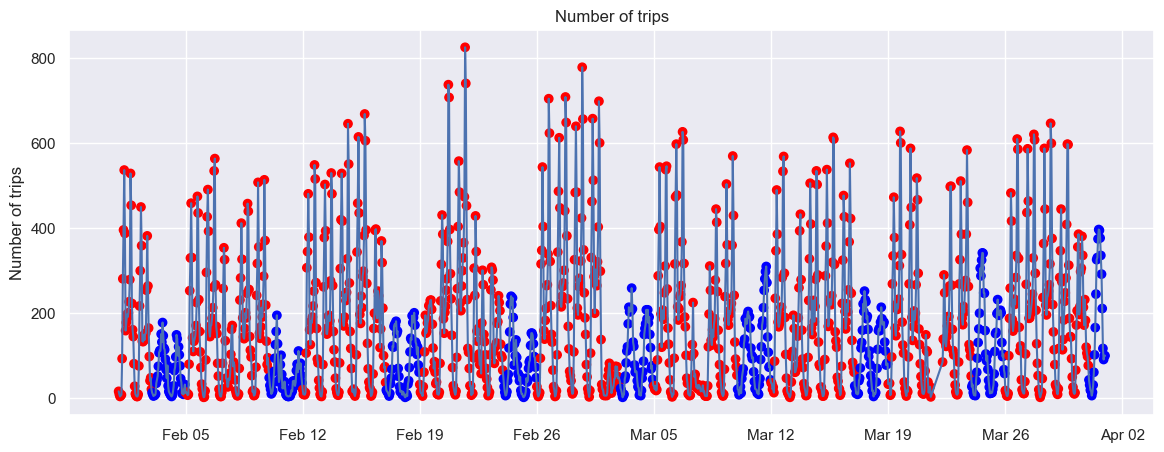

In [40]:
import matplotlib.dates as mdates
weekends=trips_per_hour.loc['2018-02':'2018-03', 'num_trips'].index.weekday>=5
colors=['blue' if x else 'red' for x in weekends]
fig, ax = plt.subplots()
ax.plot(trips_per_hour.loc['2018-02':'2018-03', 'num_trips'])
ax.scatter(trips_per_hour.loc['2018-02':'2018-03'].index, trips_per_hour.loc['2018-02':'2018-03', 'num_trips'], marker='o', linestyle='-', c=colors)
ax.set_ylabel('Number of trips')
ax.set_title('Number of trips')

# To better visualize the weekly seasonality in electricity consumption 
# we add vertical gridlines on a weekly time scale

# Set x-axis major ticks to weekly interval, on Mondays
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY))
# Format x-tick labels as 3-letter month name and day number
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'));

# Investigating all the data

In [41]:


# Make sure starttime is a datetime
df_merged_start['starttime'] = pd.to_datetime(df_merged_start['starttime'])

# Extract date and hour
df_merged_start['date'] = df_merged_start['starttime'].dt.date
df_merged_start['hour'] = df_merged_start['starttime'].dt.hour

# Group by date and hour, count trips
trips_per_hour_all = df_merged_start.groupby(['date', 'hour']).size().reset_index(name='num_trips')

trips_per_hour_all['datetime'] = pd.to_datetime(trips_per_hour_all['date'].astype(str)) + pd.to_timedelta(trips_per_hour_all['hour'], unit='h')
trips_per_hour_all.set_index('datetime', inplace=True)
trips_per_hour_all.drop(columns=['date'], inplace=True)

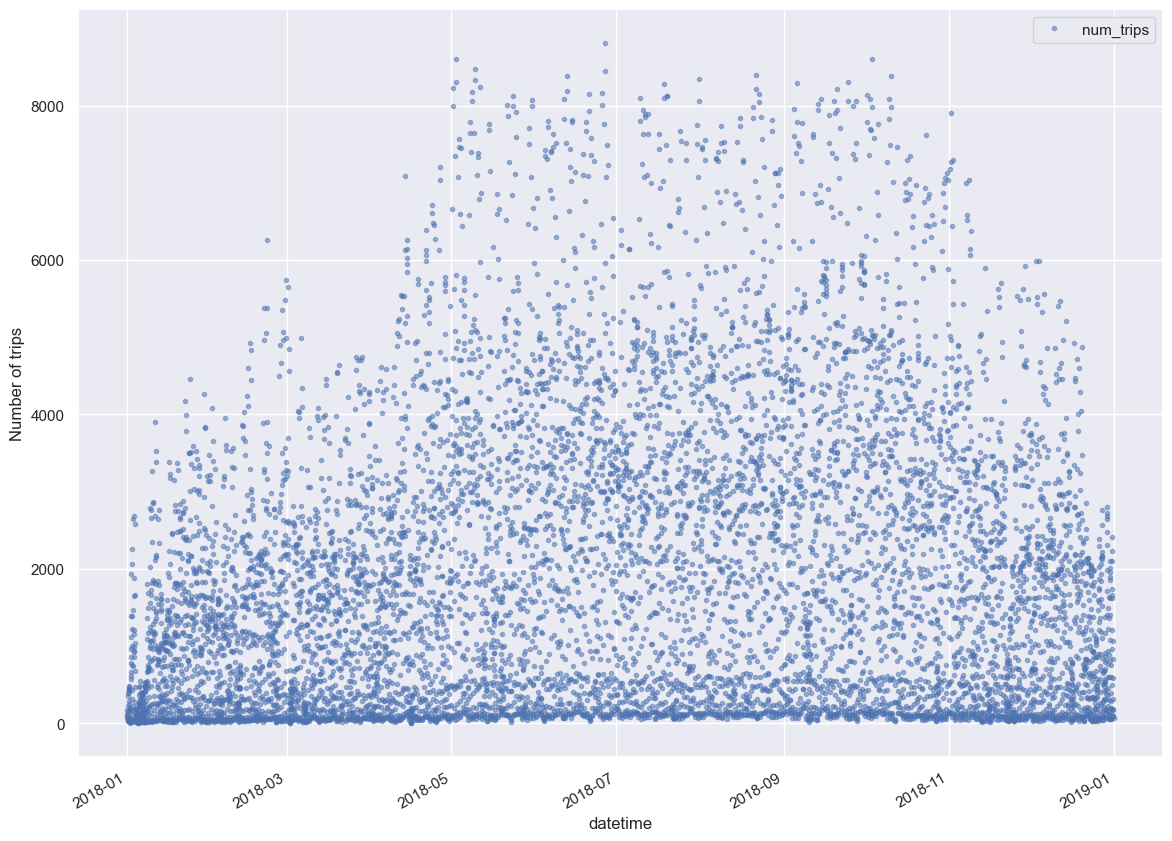

In [42]:
import seaborn as sns
sns.set_theme(rc={'figure.figsize':(14, 5)})
cols_plot = ['num_trips']
axes = trips_per_hour_all[cols_plot].plot(marker='.', alpha=0.5, linestyle='None', figsize=(14, 11), subplots=True)
for ax in axes:
    ax.set_ylabel('Number of trips')

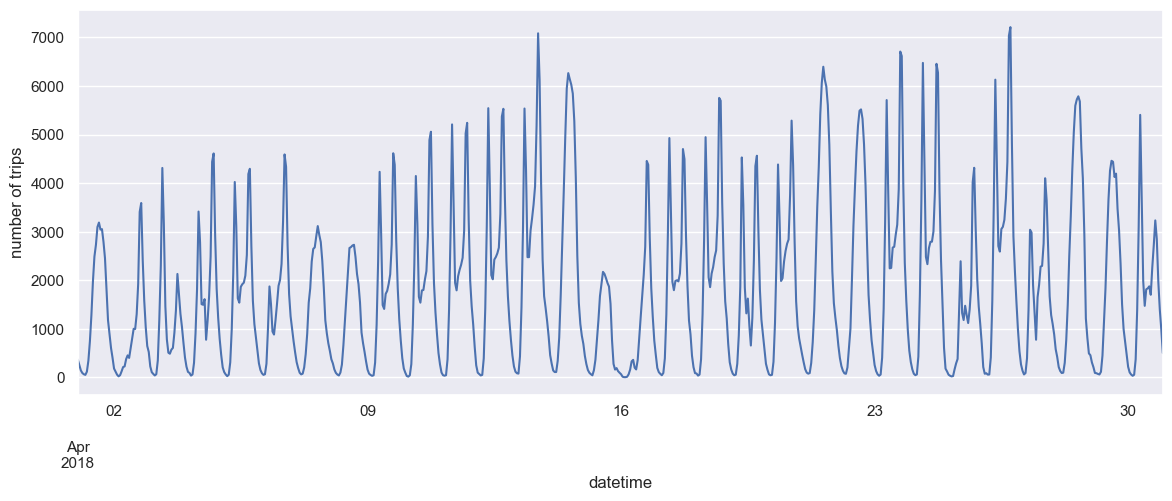

In [43]:
ax = trips_per_hour_all.loc['2018-04', 'num_trips'].plot()
ax.set_ylabel('number of trips')
plt.show()

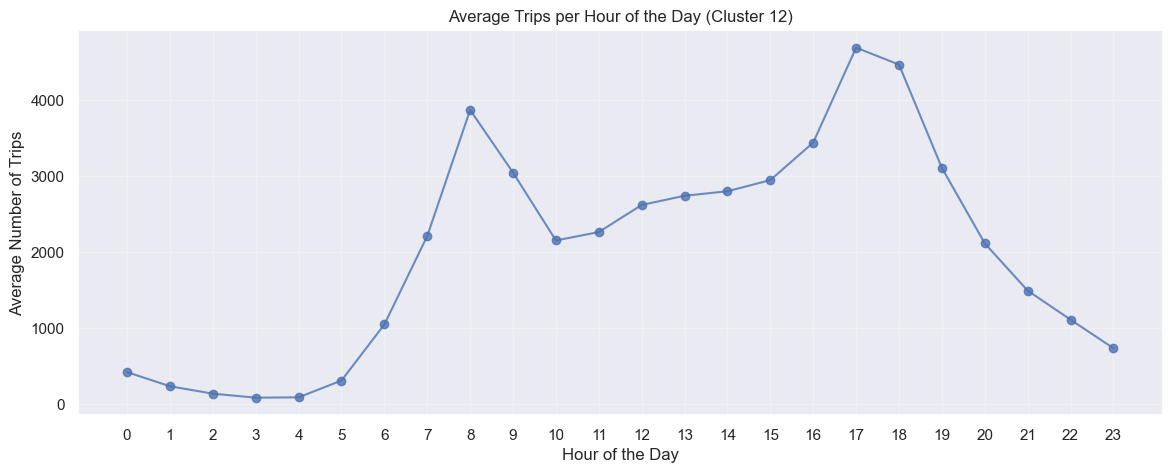

In [44]:
# Average trips per hour (0-23) across all days
avg_trips_by_hour_all = trips_per_hour_all.groupby('hour')['num_trips'].mean()
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(rc={'figure.figsize':(14, 5)})

# Plot average trips by hour
avg_trips_by_hour_all.plot(marker='o', linestyle='-', alpha=0.8)

plt.xlabel('Hour of the Day')
plt.ylabel('Average Number of Trips')
plt.title('Average Trips per Hour of the Day (Cluster 12)')
plt.xticks(range(0,24))  # ensure all hours are labeled
plt.grid(True, alpha=0.3)
plt.show()

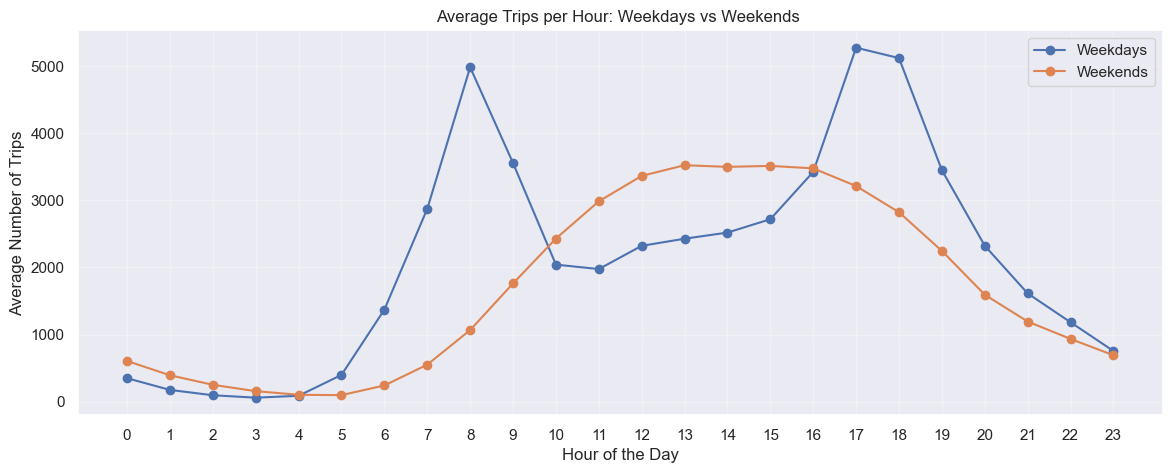

In [45]:

# Extract hour from datetime index if not already present
trips_per_hour_all['hour'] = trips_per_hour_all.index.hour
trips_per_hour_all['is_weekend'] = trips_per_hour_all.index.weekday >= 5

# Average trips per hour for weekdays
avg_weekday = trips_per_hour_all[~trips_per_hour_all['is_weekend']].groupby('hour')['num_trips'].mean()

# Average trips per hour for weekends
avg_weekend = trips_per_hour_all[trips_per_hour_all['is_weekend']].groupby('hour')['num_trips'].mean()

# Plot
sns.set(rc={'figure.figsize':(14,5)})
plt.plot(avg_weekday.index, avg_weekday.values, marker='o', linestyle='-', label='Weekdays')
plt.plot(avg_weekend.index, avg_weekend.values, marker='o', linestyle='-', label='Weekends')

plt.xlabel('Hour of the Day')
plt.ylabel('Average Number of Trips')
plt.title('Average Trips per Hour: Weekdays vs Weekends ')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

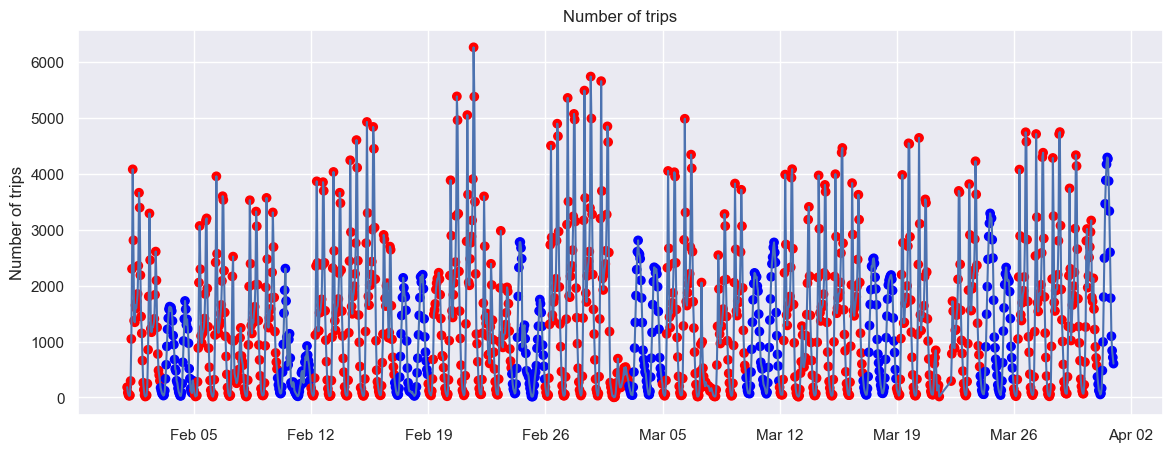

In [46]:
weekends=trips_per_hour_all.loc['2018-02':'2018-03', 'num_trips'].index.weekday>=5
colors=['blue' if x else 'red' for x in weekends]
fig, ax = plt.subplots()
ax.plot(trips_per_hour_all.loc['2018-02':'2018-03', 'num_trips'])
ax.scatter(trips_per_hour_all.loc['2018-02':'2018-03'].index, trips_per_hour_all.loc['2018-02':'2018-03', 'num_trips'], marker='o', linestyle='-', c=colors)
ax.set_ylabel('Number of trips')
ax.set_title('Number of trips')

# To better visualize the weekly seasonality in electricity consumption 
# we add vertical gridlines on a weekly time scale

# Set x-axis major ticks to weekly interval, on Mondays
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY))
# Format x-tick labels as 3-letter month name and day number
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'));

In [47]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(trips_per_hour_all['num_trips'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
   print('\t%s: %.3f' % (key, value))

ADF Statistic: -8.135703
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567


# Exploring seasonality in all the data

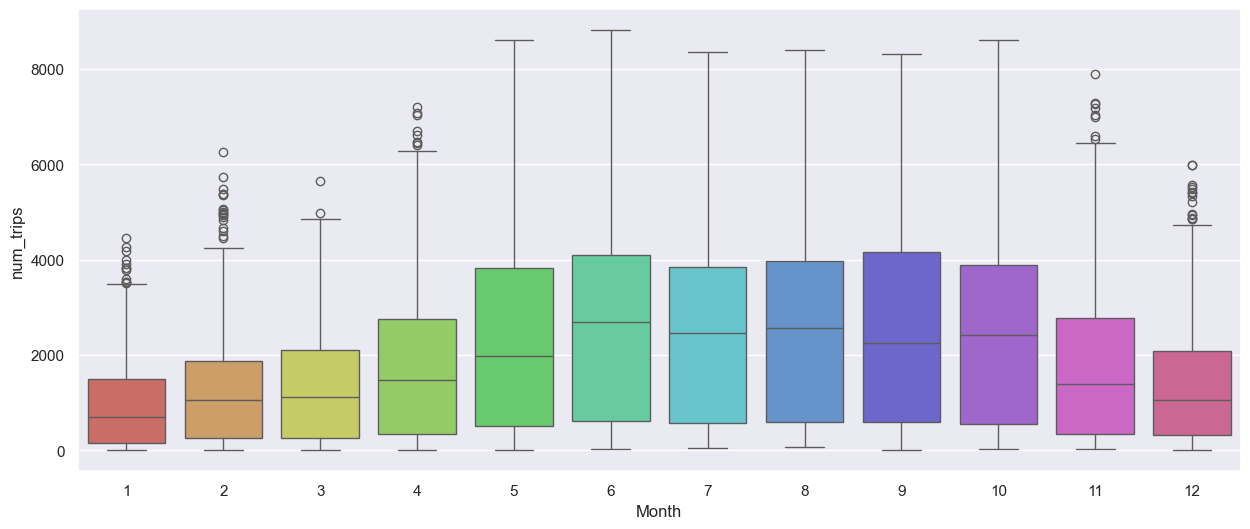

In [48]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6), sharex=True)
trips_per_hour_all['Month'] = trips_per_hour_all.index.month
sns.boxplot(data=trips_per_hour_all, x='Month', y='num_trips', ax=axes, hue='Month',palette=sns.color_palette("hls", 12),legend=False)
ax.set_ylabel('Number of trips')
ax.set_title('Boxplot of number of trips in each month')
plt.show()

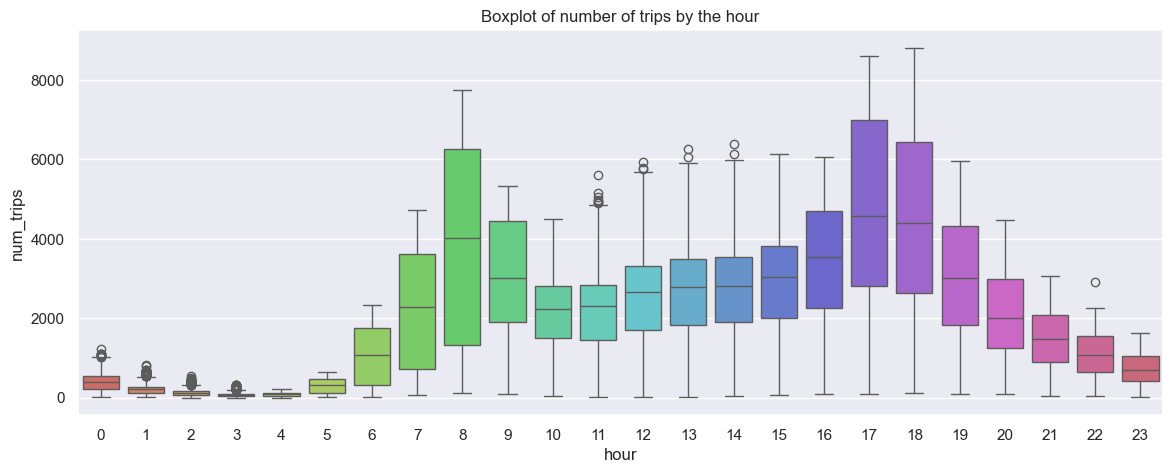

In [49]:
sns.boxplot(data=trips_per_hour_all, x='hour', y='num_trips',hue='hour',palette=sns.color_palette("hls", 24),legend=False)
plt.title('Boxplot of number of trips by the hour')
plt.show()

# Rolling average

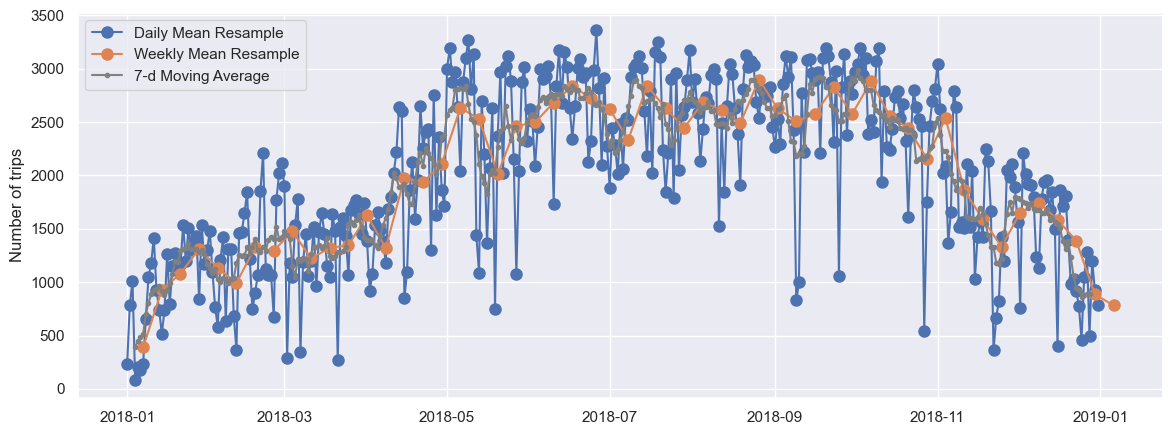

In [50]:
data_columns = ['num_trips']
opsd_daily_mean = trips_per_hour_all[data_columns].resample('D').mean()
opsd_daily_mean[:3]
opsd_weekly_mean = trips_per_hour_all[data_columns].resample('W').mean()
opsd_weekly_mean[:3]

opsd_7d = opsd_daily_mean[data_columns].rolling(7, center=True).mean()
opsd_7d.head(10)

start, end = '2018-01', '2019-01'
# Plot daily and weekly resampled time series together
fig, ax = plt.subplots()
ax.plot(opsd_daily_mean.loc[start:end, 'num_trips'],
marker='o', markersize=8, linestyle='-', label='Daily Mean Resample')
ax.plot(opsd_weekly_mean.loc[start:end, 'num_trips'],
marker='o', markersize=8, linestyle='-', label='Weekly Mean Resample')
ax.plot(opsd_7d.loc[start:end, 'num_trips'],
marker='.', linestyle='-', label='7-d Moving Average', color="grey")
ax.set_ylabel('Number of trips')
ax.legend()

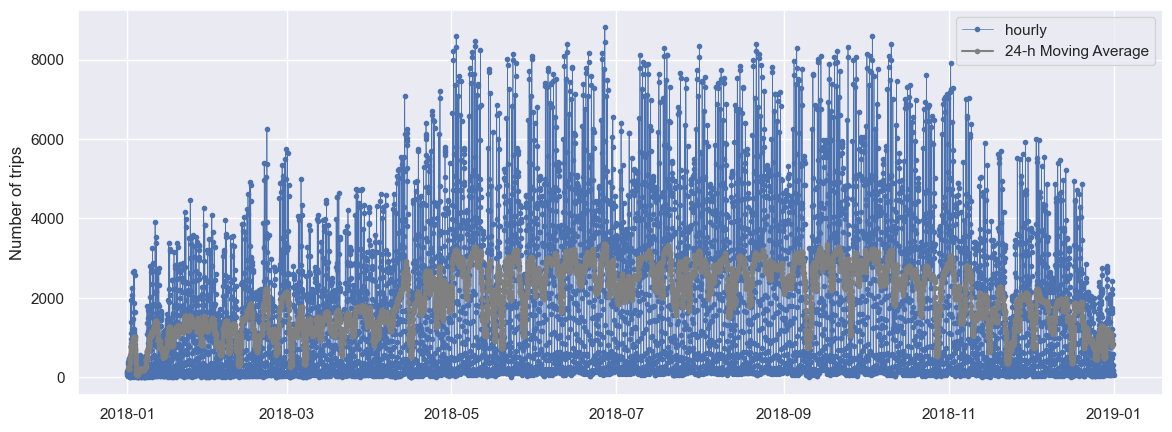

In [51]:

opsd_24h = trips_per_hour_all[data_columns].rolling(24, center=True).mean()
start, end = '2018-01', '2019-01'
# Plot daily and weekly resampled time series together
fig, ax = plt.subplots()
ax.plot(trips_per_hour_all.loc[start:end, 'num_trips'],
marker='.', linestyle='-', linewidth=0.5, label='hourly')
ax.plot(opsd_24h.loc[start:end, 'num_trips'],
marker='.', linestyle='-', label='24-h Moving Average', color="grey")
ax.set_ylabel('Number of trips')
ax.legend()

# Autocorrelation

In [52]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

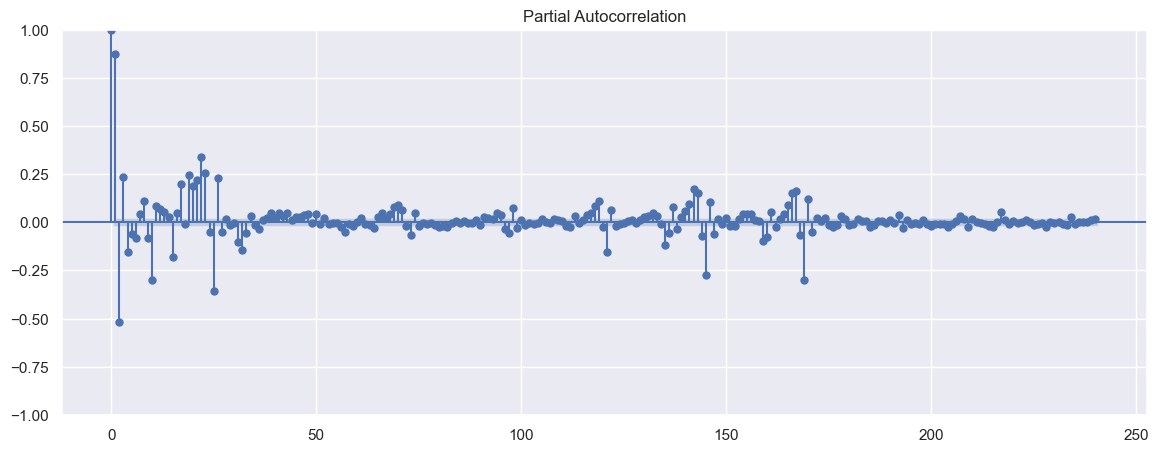

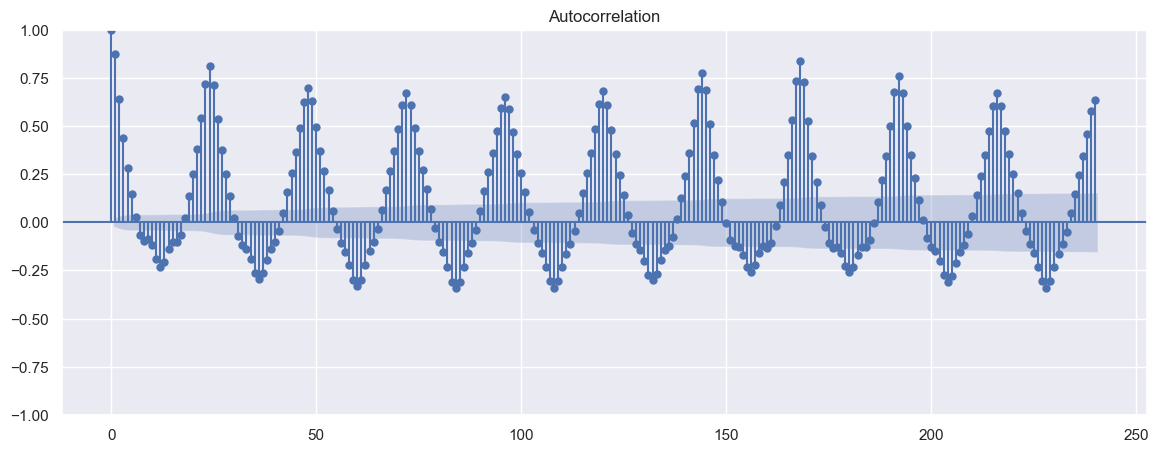

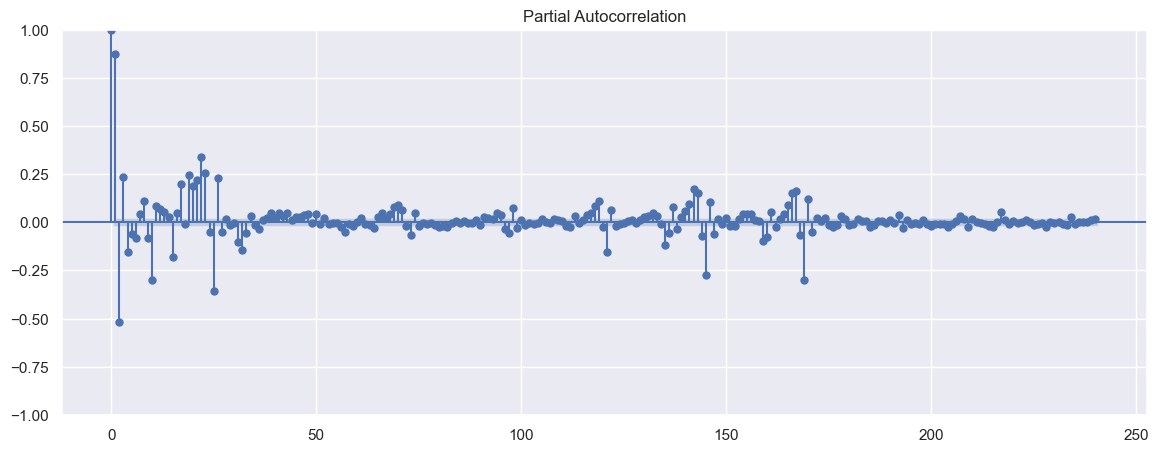

In [53]:
plot_acf(trips_per_hour_all['num_trips'],lags=10*24) # lags valgt udfra 10 dage gnage 24 timer
plot_pacf(trips_per_hour_all['num_trips'],lags=10*24)

# Further investigation of what variables to keep for our prediction model

We discussed: leaving out starttime, stoptime, and longitude and latitude for both end station and startstation. The spatial because we now just care which cluster we are in, therefore also leave out the stations ID. Starttime is relevant stop time not su much because we try to predict demand. ANd the trip duration will be kept, also weekend, birth year, most common usertype, and most common gender. Bike ID have also been left out as it seems irrelevant to know which bike goes where at this point. 

In [54]:


# Make sure starttime is a datetime
cluster_12_departures['starttime'] = pd.to_datetime(cluster_12_departures['starttime'])

# Extract date and hour
cluster_12_departures['date'] = cluster_12_departures['starttime'].dt.date
cluster_12_departures['hour'] = cluster_12_departures['starttime'].dt.hour

# Group by date and hour, count trips
trips_per_hour = cluster_12_departures.groupby(['date', 'hour'])
trips_per_hour.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend,cluster,date,hour
Trip ID,,,,,,,,,,,,,,,,,,
0,970,2018-01-01 13:50:57.434,2018-01-01 14:07:08.186,72.0,40.767272,-73.993929,505.0,40.749013,-73.988484,31956,Subscriber,1992,1,0,False,12.0,2018-01-01,13
1,723,2018-01-01 15:33:30.182,2018-01-01 15:45:33.341,72.0,40.767272,-73.993929,3255.0,40.750585,-73.994685,32536,Subscriber,1969,1,0,False,12.0,2018-01-01,15
2,496,2018-01-01 15:39:18.337,2018-01-01 15:47:35.172,72.0,40.767272,-73.993929,525.0,40.755942,-74.002116,16069,Subscriber,1956,1,0,False,12.0,2018-01-01,15
3,306,2018-01-01 15:40:13.372,2018-01-01 15:45:20.191,72.0,40.767272,-73.993929,447.0,40.763707,-73.985162,31781,Subscriber,1974,1,0,False,12.0,2018-01-01,15
4,306,2018-01-01 18:14:51.568,2018-01-01 18:19:57.642,72.0,40.767272,-73.993929,3356.0,40.774667,-73.984706,30319,Subscriber,1992,1,0,False,12.0,2018-01-01,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17548278,794,2018-12-31 23:08:37.580,2018-12-31 23:21:52.444,450.0,40.762272,-73.987882,505.0,40.749013,-73.988484,32091,Subscriber,1988,1,0,False,12.0,2018-12-31,23
17548282,501,2018-12-31 23:10:15.947,2018-12-31 23:18:37.426,422.0,40.770513,-73.988038,3171.0,40.785247,-73.976673,29089,Subscriber,1959,1,0,False,12.0,2018-12-31,23
17548295,444,2018-12-31 23:19:41.085,2018-12-31 23:27:05.789,422.0,40.770513,-73.988038,3163.0,40.773407,-73.977825,29941,Subscriber,1992,1,0,False,12.0,2018-12-31,23


In [55]:

grouped_departures = (
    cluster_12_departures.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)


In [56]:
grouped_departures['datetime'] = pd.to_datetime(grouped_departures['date'].astype(str)) + pd.to_timedelta(grouped_departures['hour'], unit='h')
grouped_departures.set_index('datetime', inplace=True)
grouped_departures.drop(columns=['date'], inplace=True)
grouped_departures.drop(columns=['hour'], inplace=True)

In [57]:
grouped_departures

,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,
2018-01-01 00:00:00,14,False,Subscriber,1,914.642857,1978.071429
2018-01-01 01:00:00,15,False,Subscriber,1,731.600000,1980.266667
2018-01-01 02:00:00,7,False,Subscriber,1,473.142857,1973.857143
2018-01-01 03:00:00,8,False,Subscriber,1,673.125000,1976.000000
2018-01-01 04:00:00,6,False,Subscriber,1,602.666667,1980.166667
...,...,...,...,...,...,...
2018-12-31 19:00:00,8,False,Subscriber,1,1057.250000,1969.250000
2018-12-31 20:00:00,16,False,Subscriber,1,2687.937500,1973.937500
2018-12-31 21:00:00,9,False,Subscriber,1,1198.222222,1981.333333


# Starting to build model

## non stationarity - hjælp
Vi kan jo se nogle klare seasonalities - how to account for them

In [58]:
result = adfuller(trips_per_hour_all['num_trips'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -8.135703
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567


## Naive model - predict same val for trip_count as 24 h before

In [59]:
# Make sure the index is a DatetimeIndex
grouped_departures.index = pd.to_datetime(grouped_departures.index)

# Define the test start date
test_start = pd.Timestamp("2018-11-01")

# Create boolean masks
train_mask = grouped_departures.index < test_start
test_mask  = grouped_departures.index >= test_start


In [60]:
def plain_moving_average(series, n):
    #write your code here
    return list([np.average(series.iloc[max(i-n,0):i-1]) for i in range(1,len(series)+1)])

def plotprediction(series, pred_series, labels=["original", "predicted"], x_axis=None, plot_intervals=False, scale=1.96, plot_anomalies=False, title="prediction"):

    plt.figure(figsize=(15,5))
    plt.title(title)
    if x_axis is None:
        x_axis=series.index
    
    plt.plot(x_axis, pred_series, "g", label=labels[1])
    plt.plot(x_axis, series, label=labels[0])
    

    # Plot confidence intervals for smoothed values

    plt.legend(loc="upper left")
    plt.grid(True)
    plt.show()

### Eval. of Naive model

In [61]:
from sklearn.metrics import r2_score, mean_absolute_error

def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def print_stats(y_test, y_preds, title="You forgot the title!"):
    print(title+": ")
    print("\tr^2=%f"%r2_score(y_test,y_preds))
    print("\tMAE=%f"%mean_absolute_error(y_test,y_preds))
    print("\tMAPE=%f"%mean_absolute_percentage_error(y_test,y_preds))

In [62]:
grouped_data_departures = pd.DataFrame(grouped_departures.trip_count.copy())
grouped_data_departures 


,trip_count
datetime,
2018-01-01 00:00:00,14
2018-01-01 01:00:00,15
2018-01-01 02:00:00,7
2018-01-01 03:00:00,8
2018-01-01 04:00:00,6
...,...
2018-12-31 19:00:00,8
2018-12-31 20:00:00,16
2018-12-31 21:00:00,9


In [63]:
import statsmodels.tsa.api as smt
import statsmodels.api as sm

lags_to_plot = 72

def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    """
        Plot time series, its ACF and PACF, calculate Dickey–Fuller test
        
        y - timeseries
        lags - how many lags to include in ACF, PACF calculation
    """
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
        
    with plt.style.context(style):    
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        
        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

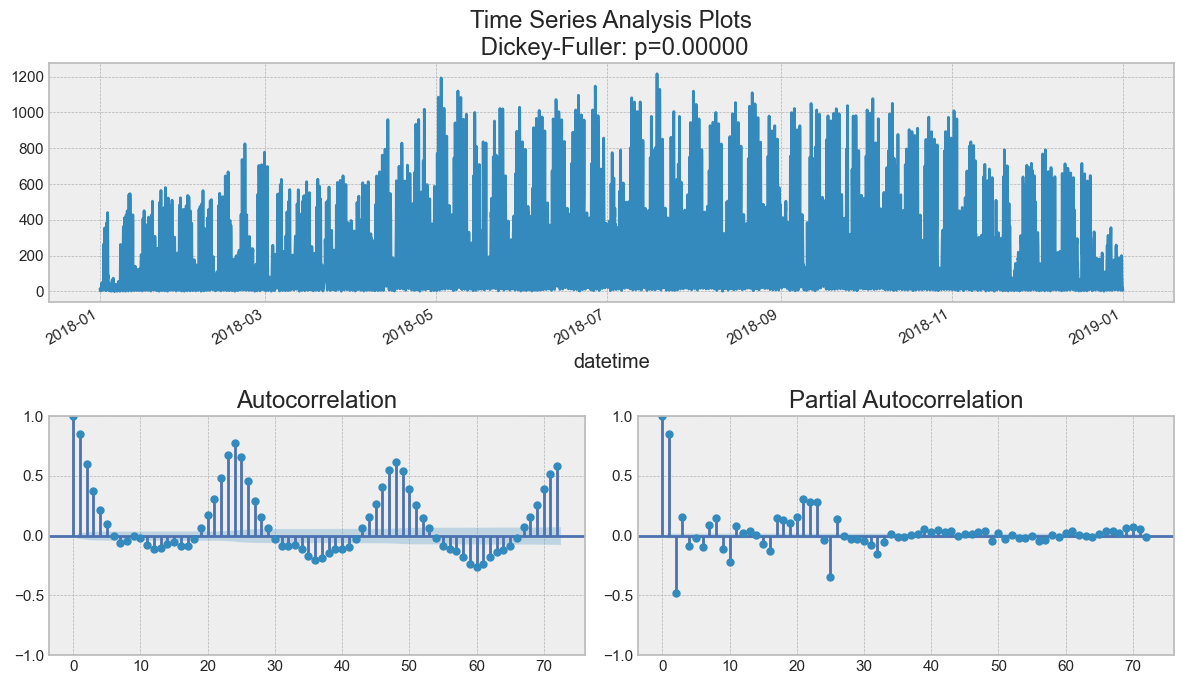

In [64]:
tsplot(grouped_data_departures.trip_count, lags=lags_to_plot)

# Adjusting for daily seasonality: 

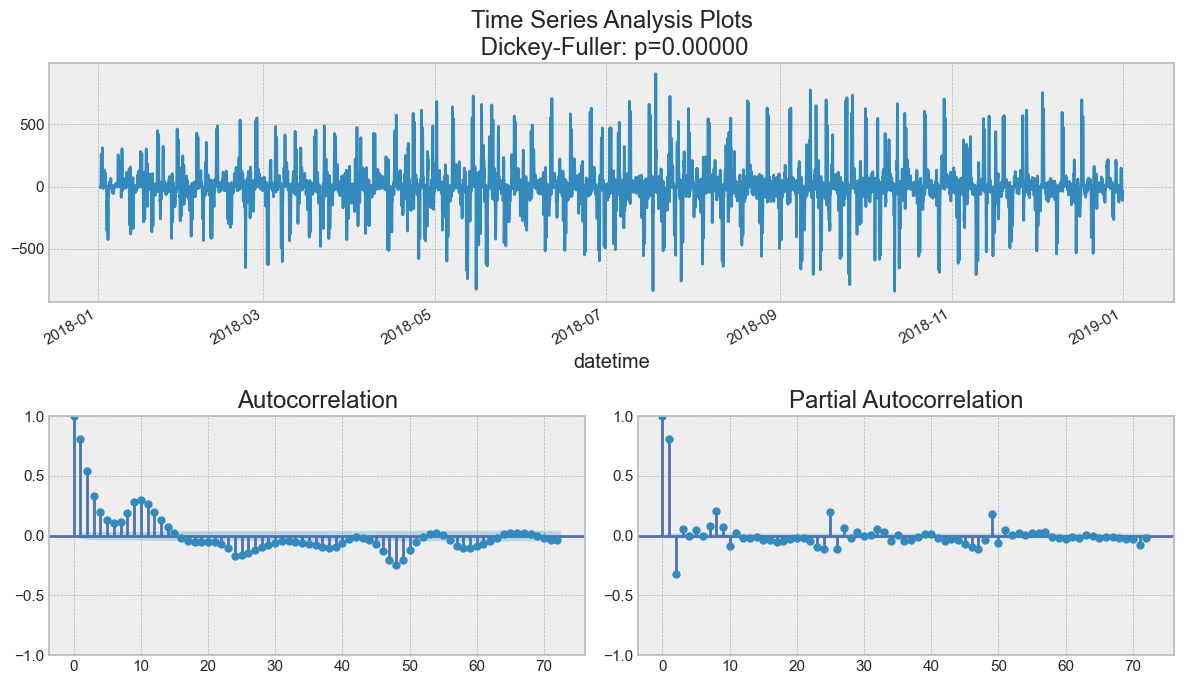

In [65]:
trip_diff = grouped_data_departures.trip_count - grouped_data_departures.trip_count.shift(24)
tsplot(trip_diff[24:], lags=lags_to_plot)

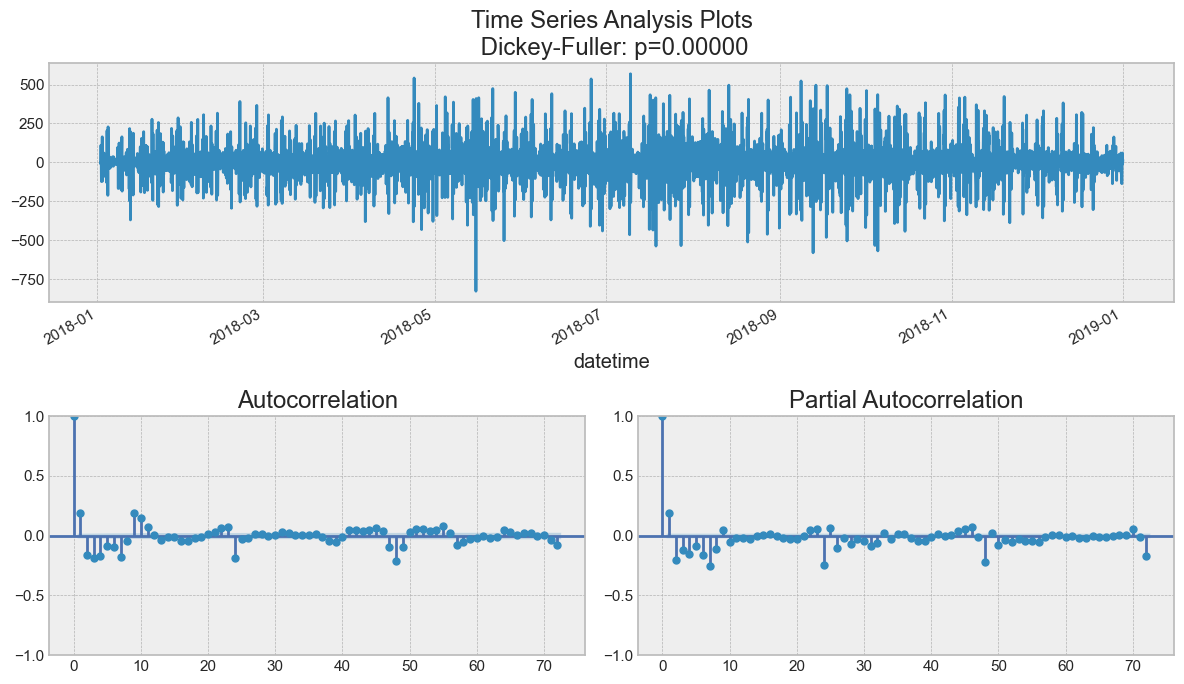

In [66]:
trip_diff = trip_diff - trip_diff.shift(1)
tsplot(trip_diff[24+1:], lags=lags_to_plot)

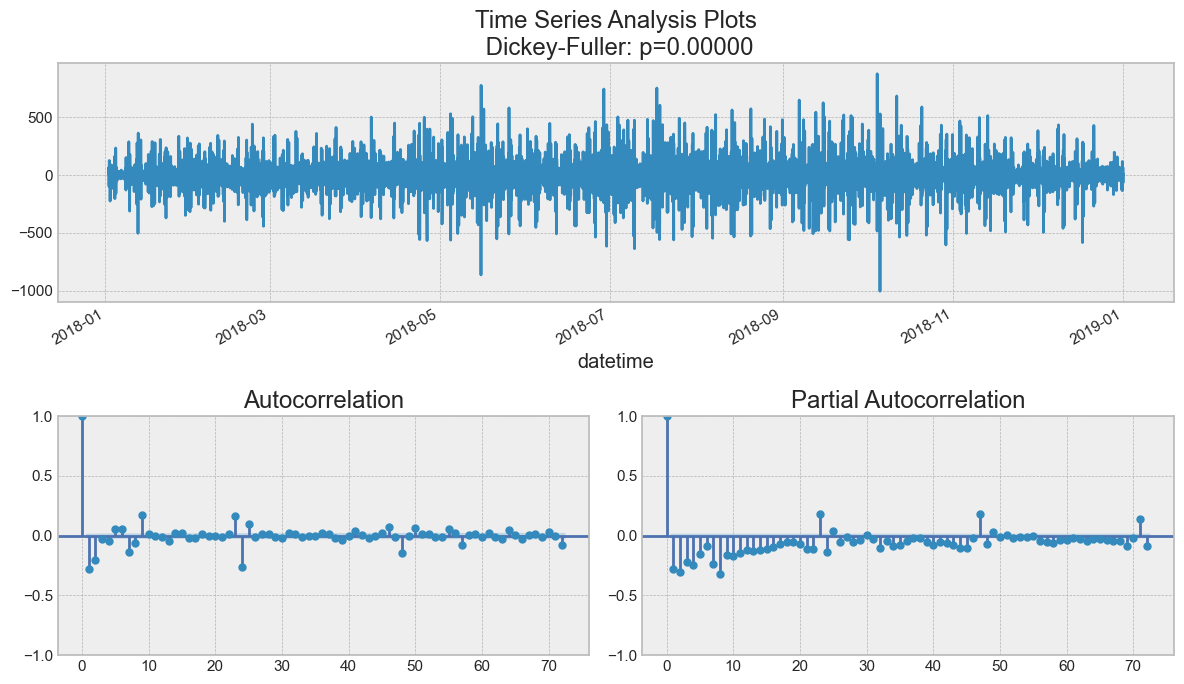

In [67]:
trip_diff = trip_diff - trip_diff.shift(1)
trip_clean = trip_diff[25:].replace([np.inf, -np.inf], np.nan).dropna()
tsplot(trip_clean, lags=lags_to_plot)

# RandomForestRegressor

## Creation

In [68]:
from sklearn.ensemble import RandomForestRegressor

# --- Create lag features for 24, 48, 72 hours ---
for lag in [24, 25, 26, 27, 28, 48, 72, 166, 167, 168, 169, 170, 171]:
    grouped_departures[f'lag_{lag}'] = grouped_departures['trip_count'].shift(lag)

# --- Calendar / time features from the datetime index ---
grouped_departures['hour']  = grouped_departures.index.hour
grouped_departures['dow']   = grouped_departures.index.weekday   # 0=Mon,...,6=Sun
grouped_departures['month'] = grouped_departures.index.month

# One-hot encode categorical variables (user type and gender)
grouped_rf = pd.get_dummies(
    grouped_departures,
    columns=['most_common_user_type', 'most_common_gender'],
    drop_first=True
)

In [69]:

# Drop first rows where lag features are NaN (because of shifting)
grouped_rf = grouped_rf.dropna(subset=['lag_24', 'lag_48', 'lag_72', 'lag_171'])


In [70]:
grouped_rf.head()

,trip_count,is_weekend,duration_mean,birth_mean,lag_24,lag_25,lag_26,lag_27,lag_28,lag_48,...,lag_168,lag_169,lag_170,lag_171,hour,dow,month,most_common_user_type_Subscriber,most_common_gender_1,most_common_gender_2
datetime,,,,,,,,,,,,,,,,,,,,,
2018-01-08 09:00:00,238,False,732.054622,1978.722689,22.0,7.0,10.0,2.0,2.0,14.0,...,8.0,7.0,15.0,14.0,9,0,1,True,True,False
2018-01-08 10:00:00,72,False,1214.875000,1977.694444,24.0,22.0,7.0,10.0,2.0,16.0,...,6.0,8.0,7.0,15.0,10,0,1,True,True,False
2018-01-08 11:00:00,67,False,1014.432836,1976.462687,35.0,24.0,22.0,7.0,10.0,21.0,...,2.0,6.0,8.0,7.0,11,0,1,True,True,False
2018-01-08 12:00:00,58,False,593.189655,1976.120690,35.0,35.0,24.0,22.0,7.0,30.0,...,6.0,2.0,6.0,8.0,12,0,1,True,True,False
2018-01-08 13:00:00,85,False,615.941176,1976.600000,54.0,35.0,35.0,24.0,22.0,28.0,...,7.0,6.0,2.0,6.0,13,0,1,True,True,False


In [71]:
# Use the same temporal split as before
test_start = pd.Timestamp("2018-11-01")
test_end   = pd.Timestamp("2018-12-31")

train_mask_rf = grouped_rf.index < test_start
test_mask_rf  = (grouped_rf.index >= test_start) & (grouped_rf.index <= test_end)

# Define feature columns (exclude target and naive copy column)
feature_cols = [
    c for c in grouped_rf.columns 
    if c != 'trip_count'
]

X_train = grouped_rf.loc[train_mask_rf, feature_cols]
y_train = grouped_rf.loc[train_mask_rf, 'trip_count']

X_test  = grouped_rf.loc[test_mask_rf, feature_cols]
y_test  = grouped_rf.loc[test_mask_rf, 'trip_count']


In [72]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("===TRAINING SET STATS===")
print_stats(y_train, rf.predict(X_train), "Random Forest (lags 24/48/72) – departures, cluster 12")
print("===TEST SET STATS===")
print_stats(y_test, y_pred_rf, "Random Forest (lags 24/48/72) – departures, cluster 12")


===TRAINING SET STATS===
Random Forest (lags 24/48/72) – departures, cluster 12: 
	r^2=0.976879
	MAE=19.085983
	MAPE=19.501890
===TEST SET STATS===
Random Forest (lags 24/48/72) – departures, cluster 12: 
	r^2=0.722857
	MAE=55.299581
	MAPE=83.919379


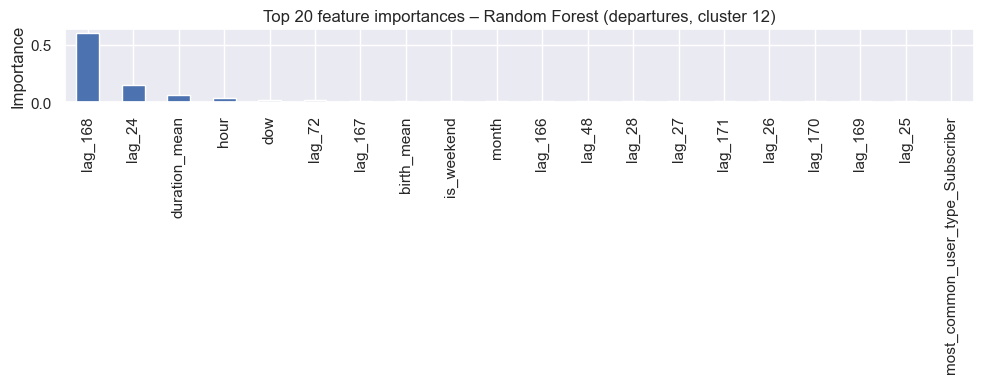

lag_24                  1.478969e-01
lag_48                  9.649610e-03
lag_72                  1.596463e-02
most_common_gender_1    5.842075e-08
dtype: float64


In [73]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
imp_top = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,4))
imp_top.plot(kind='bar')
plt.title("Top 20 feature importances – Random Forest (departures, cluster 12)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# If you want to see just the lags:
print(importances[['lag_24', 'lag_48', 'lag_72', 'most_common_gender_1']])


In [74]:
val_start = pd.Timestamp("2018-10-01")
test_start = pd.Timestamp("2018-11-01")

train_mask = grouped_rf.index < val_start
val_mask   = (grouped_rf.index >= val_start) & (grouped_rf.index < test_start)
test_mask  = grouped_rf.index >= test_start

X_train = grouped_rf.loc[train_mask, feature_cols]
y_train = grouped_rf.loc[train_mask, 'trip_count']

X_val = grouped_rf.loc[val_mask, feature_cols]
y_val = grouped_rf.loc[val_mask, 'trip_count']

X_test = grouped_rf.loc[test_mask, feature_cols]
y_test = grouped_rf.loc[test_mask, 'trip_count']


In [75]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    bootstrap=False
)

rf.fit(X_train, y_train)


,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [76]:
y_val_pred = rf.predict(X_val)
print_stats(y_val, y_val_pred, "Random Forest – VALIDATION SET")

Random Forest – VALIDATION SET: 
	r^2=0.839668
	MAE=60.566207
	MAPE=35.219640


In [77]:
y_train_pred = rf.predict(X_train)
y_test_pred  = rf.predict(X_test)

print_stats(y_train, y_train_pred, "TRAIN")
print_stats(y_val,   y_val_pred,   "VALIDATION")
print_stats(y_test,  y_test_pred,  "TEST")


TRAIN: 
	r^2=0.987505
	MAE=11.910524
	MAPE=9.374826
VALIDATION: 
	r^2=0.839668
	MAE=60.566207
	MAPE=35.219640
TEST: 
	r^2=0.480278
	MAE=79.489620
	MAPE=105.496064


In [78]:
from sklearn.metrics import mean_squared_error

def mean_squared_error_custom(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)


In [79]:
def print_stats(y_test, y_preds, title="You forgot the title!"):
    mse = mean_squared_error(y_test, y_preds)

    print(title + ":")
    print(f"\tr^2   = {r2_score(y_test, y_preds):.6f}")
    print(f"\tMAE   = {mean_absolute_error(y_test, y_preds):.6f}")
    print(f"\tMAPE  = {mean_absolute_percentage_error(y_test, y_preds):.6f}")
    print(f"\tMSE   = {mse:.6f}")


In [80]:
y_train_pred = rf.predict(X_train)
y_val_pred   = rf.predict(X_val)
y_test_pred  = rf.predict(X_test)

print_stats(y_train, y_train_pred, "TRAIN")
print_stats(y_val,   y_val_pred,   "VALIDATION")
print_stats(y_test,  y_test_pred,  "TEST")


TRAIN:
	r^2   = 0.987505
	MAE   = 11.910524
	MAPE  = 9.374826
	MSE   = 617.394967
VALIDATION:
	r^2   = 0.839668
	MAE   = 60.566207
	MAPE  = 35.219640
	MSE   = 9437.936627
TEST:
	r^2   = 0.480278
	MAE   = 79.489620
	MAPE  = 105.496064
	MSE   = 16802.389223


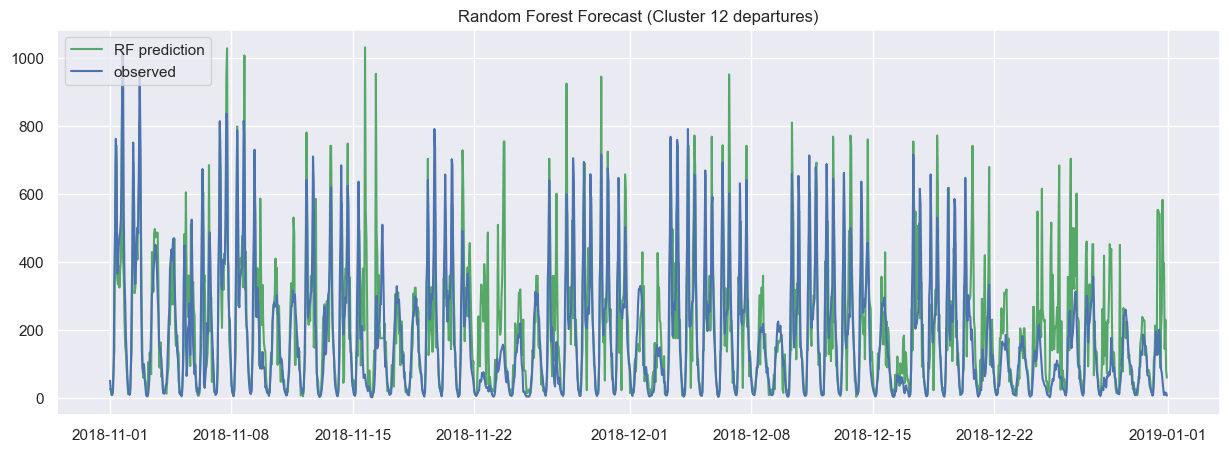

In [81]:
# --- Random Forest prediction plot ---

# Use the same index as the test set to ensure alignment
rf_pred_series = pd.Series(y_test_pred, index=X_test.index)

# Get the actual values for the same time period as the test predictions
actual_series = grouped_rf.loc[X_test.index, 'trip_count']

plotprediction(
    series = actual_series,
    pred_series = rf_pred_series,
    labels = ['observed', 'RF prediction'],
    title = "Random Forest Forecast (Cluster 12 departures)"
)


# PCA Decomposition

## On Covariance matrix

In [82]:
from sklearn.decomposition import PCA
# Define features and target
features = grouped_rf.drop(columns=['trip_count'])
target = grouped_rf['trip_count']
# Split into training and testing sets
X_train = features[train_mask]
y_train = target[train_mask]
X_test = features[test_mask]
y_test = target[test_mask]
# Initialize and fit PCA
pca = PCA()  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train)

In [83]:
X_test_pca = pca.transform(X_test)

# Check the shape of the transformed data
X_train_pca.shape, X_test_pca.shape

((6344, 22), (1462, 22))

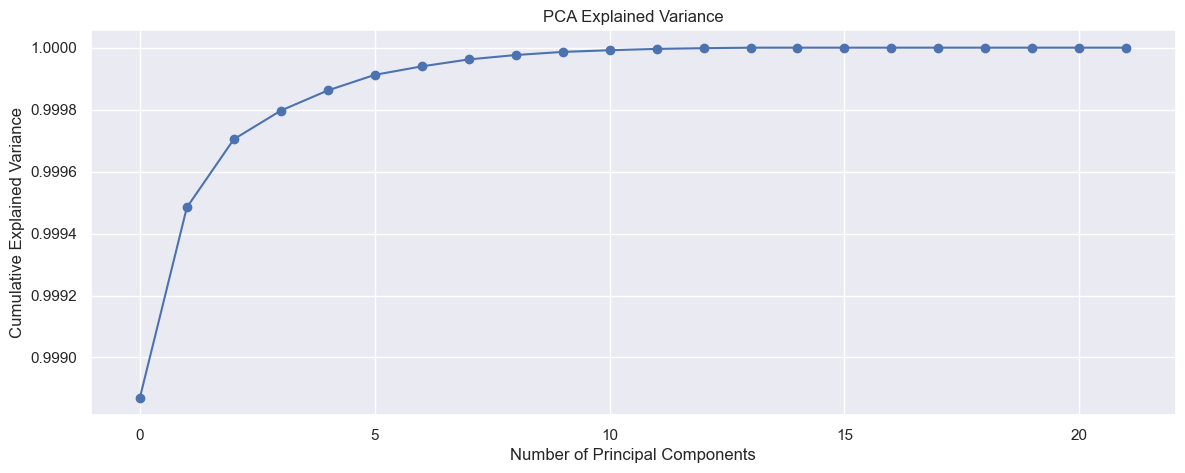

In [84]:
plt.plot(pca.explained_variance_ratio_.cumsum(), '-ob')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

## On Correlation Matrix

In [85]:
from sklearn.decomposition import PCA
# Define features and target
features = grouped_rf.drop(columns=['trip_count'])
target = grouped_rf['trip_count']
# Split into training and testing sets
features = (features - features.mean()) / features.std()
X_train = features[train_mask]
y_train = target[train_mask]
X_test = features[test_mask]
y_test = target[test_mask]
# Initialize and fit PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train)

In [86]:
X_test_pca = pca.transform(X_test)

# Check the shape of the transformed data
X_train_pca.shape, X_test_pca.shape

((6344, 13), (1462, 13))

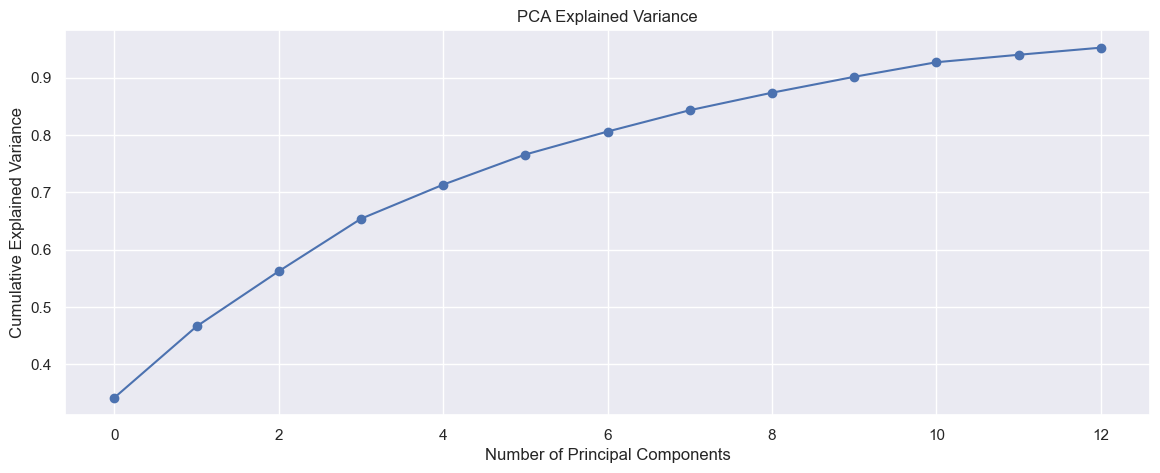

In [87]:
plt.plot(pca.explained_variance_ratio_.cumsum(), '-ob')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

In [88]:
len(pca.components_)

13

In [89]:
rf_pca = RandomForestRegressor(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X_train_pca, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [90]:
y_train_pred = rf_pca.predict(X_train_pca)
y_test_pred  = rf_pca.predict(X_test_pca)

print_stats(y_train, y_train_pred, "TRAIN")
print_stats(y_test,  y_test_pred,  "TEST")


TRAIN:
	r^2   = 0.847249
	MAE   = 56.350842
	MAPE  = 74.971942
	MSE   = 7547.396608
TEST:
	r^2   = 0.578648
	MAE   = 73.606037
	MAPE  = 119.838660
	MSE   = 13622.126988


# Add weather data to account for day deviating from trend and seasonality

In [91]:
# === Load NYC weather data ===
weather = pd.read_csv("nyc_weather_2018.csv")

# Inspect columns if you want
print(weather.columns)
weather.head()


Index(['temperature_2m (°C)', 'precipitation (mm)', 'rain (mm)',
       'cloudcover (%)', 'cloudcover_low (%)', 'cloudcover_mid (%)',
       'cloudcover_high (%)', 'windspeed_10m (km/h)', 'winddirection_10m (°)'],
      dtype='object')


,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),windspeed_10m (km/h),winddirection_10m (°)
0,-11.1,0.0,0.0,0.0,0.0,0.0,0.0,9.4,302.0
1,-11.5,0.0,0.0,0.0,0.0,0.0,0.0,10.1,297.0
2,-11.8,0.0,0.0,0.0,0.0,0.0,0.0,12.3,302.0
3,-12.2,0.0,0.0,0.0,0.0,0.0,0.0,13.9,307.0
4,-12.2,0.0,0.0,0.0,0.0,0.0,0.0,14.3,309.0


In [92]:
# Create an hourly datetime index for 2018
weather['datetime'] = pd.date_range(
    start='2018-01-01 00:00',
    periods=len(weather),
    freq='H'
)
weather = weather.set_index('datetime')


/var/folders/2q/0s6yfy4s7cdcl3184vyy5v_w0000gp/T/ipykernel_6513/1390128639.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  weather['datetime'] = pd.date_range(


In [93]:
# Join weather data on the datetime index
grouped_rf_weather = grouped_rf.join(weather, how='left')

grouped_rf_weather.head()


,trip_count,is_weekend,duration_mean,birth_mean,lag_24,lag_25,lag_26,lag_27,lag_28,lag_48,...,most_common_gender_2,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),windspeed_10m (km/h),winddirection_10m (°)
datetime,,,,,,,,,,,,,,,,,,,,,
2018-01-08 09:00:00,238,False,732.054622,1978.722689,22.0,7.0,10.0,2.0,2.0,14.0,...,False,-8.7,0.0,0.0,2.0,2.0,1.0,0.0,13.6,220.0
2018-01-08 10:00:00,72,False,1214.875000,1977.694444,24.0,22.0,7.0,10.0,2.0,16.0,...,False,-9.1,0.0,0.0,24.0,3.0,15.0,42.0,10.5,218.0
2018-01-08 11:00:00,67,False,1014.432836,1976.462687,35.0,24.0,22.0,7.0,10.0,21.0,...,False,-9.1,0.0,0.0,50.0,3.0,50.0,59.0,10.3,216.0
2018-01-08 12:00:00,58,False,593.189655,1976.120690,35.0,35.0,24.0,22.0,7.0,30.0,...,False,-9.1,0.0,0.0,39.0,3.0,61.0,0.0,9.0,217.0
2018-01-08 13:00:00,85,False,615.941176,1976.600000,54.0,35.0,35.0,24.0,22.0,28.0,...,False,-8.8,0.0,0.0,63.0,2.0,65.0,73.0,7.9,204.0


In [94]:
val_start = pd.Timestamp("2018-10-01")
test_start = pd.Timestamp("2018-11-01")

train_mask = grouped_rf.index < val_start
val_mask   = (grouped_rf.index >= val_start) & (grouped_rf.index < test_start)
test_mask  = grouped_rf.index >= test_start


In [95]:
# All features except target and naive baseline
feature_cols_weather = [
    c for c in grouped_rf_weather.columns
    if c not in ['trip_count', 'copy_pred']
]

X_train_w = grouped_rf_weather.loc[train_mask, feature_cols_weather]
y_train_w = grouped_rf_weather.loc[train_mask, 'trip_count']

X_val_w   = grouped_rf_weather.loc[val_mask, feature_cols_weather]
y_val_w   = grouped_rf_weather.loc[val_mask, 'trip_count']

X_test_w  = grouped_rf_weather.loc[test_mask, feature_cols_weather]
y_test_w  = grouped_rf_weather.loc[test_mask, 'trip_count']


In [96]:
from sklearn.ensemble import RandomForestRegressor

rf_weather = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_weather.fit(X_train_w, y_train_w)


,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [97]:
y_train_pred_w = rf_weather.predict(X_train_w)
y_val_pred_w   = rf_weather.predict(X_val_w)
y_test_pred_w  = rf_weather.predict(X_test_w)

print_stats(y_train_w, y_train_pred_w, "TRAIN (with weather)")
print_stats(y_val_w,   y_val_pred_w,   "VALIDATION (with weather)")
print_stats(y_test_w,  y_test_pred_w,  "TEST (with weather)")


TRAIN (with weather):
	r^2   = 0.980118
	MAE   = 17.649678
	MAPE  = 17.700174
	MSE   = 982.349027
VALIDATION (with weather):
	r^2   = 0.926643
	MAE   = 39.483002
	MAPE  = 26.850033
	MSE   = 4318.168484
TEST (with weather):
	r^2   = 0.762394
	MAE   = 52.731605
	MAPE  = 75.210600
	MSE   = 7681.712491


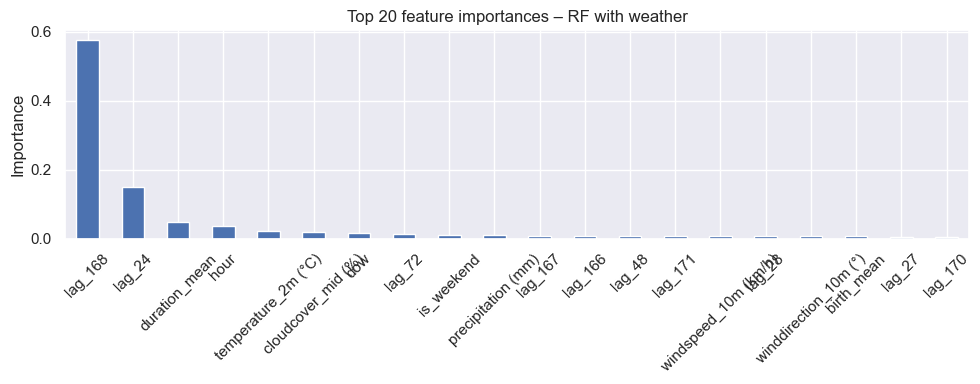

In [98]:
importances_w = pd.Series(rf_weather.feature_importances_, index=feature_cols_weather)
imp_top_w = importances_w.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,4))
imp_top_w.plot(kind='bar')
plt.title("Top 20 feature importances – RF with weather")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [99]:
# If not already done earlier:
weather = pd.read_csv("nyc_weather_2018.csv")

# Create hourly datetime index for 2018
weather['datetime'] = pd.date_range(
    start='2018-01-01 00:00',
    periods=len(weather),
    freq='h'
)
weather = weather.set_index('datetime')

# Join weather to grouped_rf (cluster 12 departures)
grouped_rf_weather = grouped_rf.join(weather, how='left')

grouped_rf_weather[['trip_count', 'temperature_2m (°C)', 'precipitation (mm)']].head()


,trip_count,temperature_2m (°C),precipitation (mm)
datetime,,,
2018-01-08 09:00:00,238,-8.7,0.0
2018-01-08 10:00:00,72,-9.1,0.0
2018-01-08 11:00:00,67,-9.1,0.0
2018-01-08 12:00:00,58,-9.1,0.0
2018-01-08 13:00:00,85,-8.8,0.0


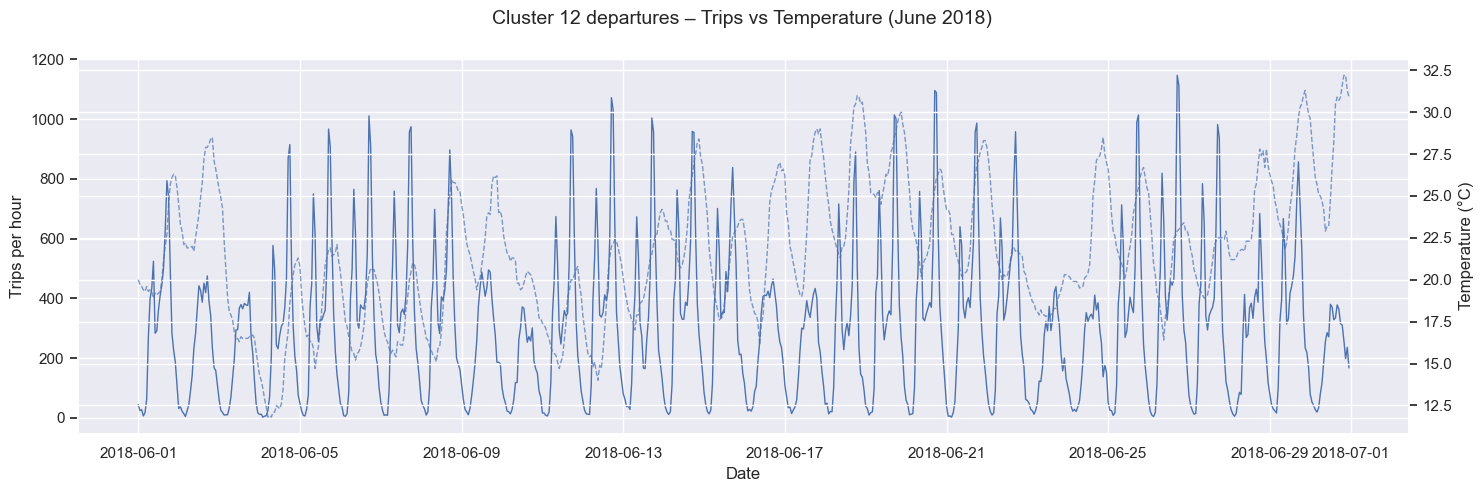

In [100]:
import matplotlib.pyplot as plt

# Pick a month to visualize
start, end = '2018-06-01', '2018-07-01'
mask = (grouped_rf_weather.index >= start) & (grouped_rf_weather.index < end)
data_month = grouped_rf_weather.loc[mask]

fig, ax1 = plt.subplots(figsize=(15,5))

# Trips (left axis)
ax1.plot(data_month.index, data_month['trip_count'], label='Trips per hour', linewidth=1)
ax1.set_xlabel('Date')
ax1.set_ylabel('Trips per hour')
ax1.tick_params(axis='y')

# Temperature (right axis)
ax2 = ax1.twinx()
ax2.plot(data_month.index, data_month['temperature_2m (°C)'], label='Temperature (°C)', linewidth=1, alpha=0.7, linestyle='--')
ax2.set_ylabel('Temperature (°C)')
ax2.tick_params(axis='y')

# Title + legend
fig.suptitle('Cluster 12 departures – Trips vs Temperature (June 2018)', fontsize=14)
fig.tight_layout()
plt.show()


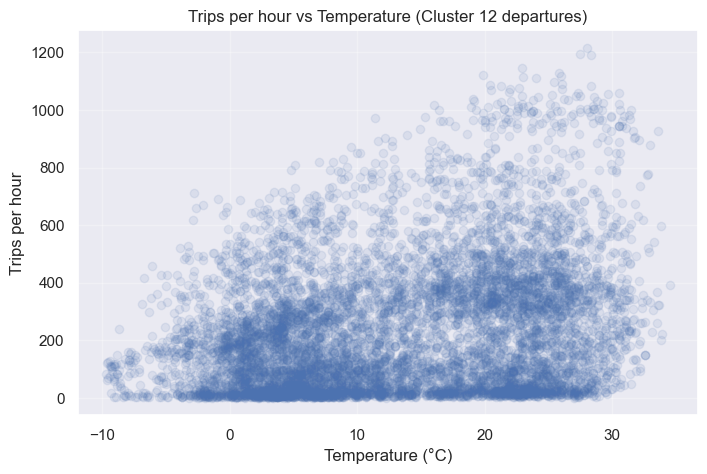

In [101]:
import matplotlib.pyplot as plt

sample = grouped_rf_weather[['trip_count', 'temperature_2m (°C)']].dropna()

plt.figure(figsize=(8,5))
plt.scatter(sample['temperature_2m (°C)'], sample['trip_count'], alpha=0.1)
plt.xlabel('Temperature (°C)')
plt.ylabel('Trips per hour')
plt.title('Trips per hour vs Temperature (Cluster 12 departures)')
plt.grid(alpha=0.3)
plt.show()


/var/folders/2q/0s6yfy4s7cdcl3184vyy5v_w0000gp/T/ipykernel_6513/2672076093.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_trips_by_temp = sample.groupby(temp_bin)['trip_count'].mean()


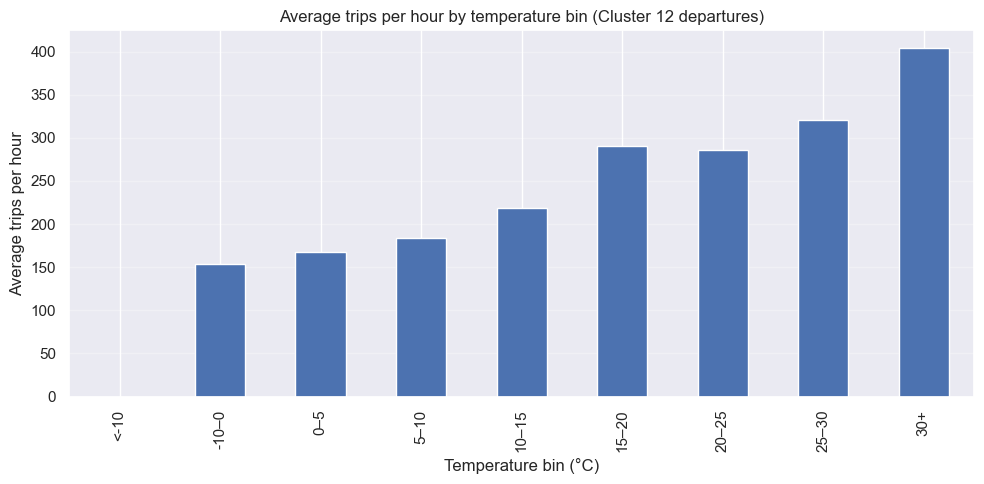

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

sample = grouped_rf_weather[['trip_count', 'temperature_2m (°C)']].dropna()

# Define temperature bins
bins = [-20, -10, 0, 5, 10, 15, 20, 25, 30, 40]
labels = ['<-10', '-10–0', '0–5', '5–10', '10–15', '15–20', '20–25', '25–30', '30+']

temp_bin = pd.cut(sample['temperature_2m (°C)'], bins=bins, labels=labels, include_lowest=True)
avg_trips_by_temp = sample.groupby(temp_bin)['trip_count'].mean()

plt.figure(figsize=(10,5))
avg_trips_by_temp.plot(kind='bar')
plt.xlabel('Temperature bin (°C)')
plt.ylabel('Average trips per hour')
plt.title('Average trips per hour by temperature bin (Cluster 12 departures)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [103]:
# --- Weather prep (only once) ---
weather = pd.read_csv("nyc_weather_2018.csv")

# Create an hourly datetime index (adjust start date if needed)
weather['datetime'] = pd.date_range(
    start='2018-01-01 00:00',
    periods=len(weather),
    freq='H'
)
weather = weather.set_index('datetime')

# --- Join weather to grouped_rf (cluster 12 departures) ---
grouped_rf_weather = grouped_rf.join(weather, how='left')
grouped_rf_weather.head()


/var/folders/2q/0s6yfy4s7cdcl3184vyy5v_w0000gp/T/ipykernel_6513/2127341572.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  weather['datetime'] = pd.date_range(


,trip_count,is_weekend,duration_mean,birth_mean,lag_24,lag_25,lag_26,lag_27,lag_28,lag_48,...,most_common_gender_2,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),windspeed_10m (km/h),winddirection_10m (°)
datetime,,,,,,,,,,,,,,,,,,,,,
2018-01-08 09:00:00,238,False,732.054622,1978.722689,22.0,7.0,10.0,2.0,2.0,14.0,...,False,-8.7,0.0,0.0,2.0,2.0,1.0,0.0,13.6,220.0
2018-01-08 10:00:00,72,False,1214.875000,1977.694444,24.0,22.0,7.0,10.0,2.0,16.0,...,False,-9.1,0.0,0.0,24.0,3.0,15.0,42.0,10.5,218.0
2018-01-08 11:00:00,67,False,1014.432836,1976.462687,35.0,24.0,22.0,7.0,10.0,21.0,...,False,-9.1,0.0,0.0,50.0,3.0,50.0,59.0,10.3,216.0
2018-01-08 12:00:00,58,False,593.189655,1976.120690,35.0,35.0,24.0,22.0,7.0,30.0,...,False,-9.1,0.0,0.0,39.0,3.0,61.0,0.0,9.0,217.0
2018-01-08 13:00:00,85,False,615.941176,1976.600000,54.0,35.0,35.0,24.0,22.0,28.0,...,False,-8.8,0.0,0.0,63.0,2.0,65.0,73.0,7.9,204.0


In [104]:
val_start  = pd.Timestamp("2018-10-01")
test_start = pd.Timestamp("2018-11-01")

train_mask = grouped_rf_weather.index < val_start
val_mask   = (grouped_rf_weather.index >= val_start) & (grouped_rf_weather.index < test_start)
test_mask  = grouped_rf_weather.index >= test_start


In [105]:
from sklearn.ensemble import RandomForestRegressor

# Features: everything except target + naive copy
feature_cols_no_w = [
    c for c in grouped_rf.columns
    if c not in ['trip_count', 'copy_pred']
]

X_train_no_w = grouped_rf.loc[train_mask, feature_cols_no_w]
y_train      = grouped_rf.loc[train_mask, 'trip_count']

X_val_no_w   = grouped_rf.loc[val_mask, feature_cols_no_w]
y_val        = grouped_rf.loc[val_mask, 'trip_count']

X_test_no_w  = grouped_rf.loc[test_mask, feature_cols_no_w]
y_test       = grouped_rf.loc[test_mask, 'trip_count']

rf_no_w = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_no_w.fit(X_train_no_w, y_train)

y_train_pred_no_w = rf_no_w.predict(X_train_no_w)
y_val_pred_no_w   = rf_no_w.predict(X_val_no_w)
y_test_pred_no_w  = rf_no_w.predict(X_test_no_w)

print_stats(y_train, y_train_pred_no_w, "TRAIN – RF without weather")
print_stats(y_val,   y_val_pred_no_w,   "VALIDATION – RF without weather")
print_stats(y_test,  y_test_pred_no_w,  "TEST – RF without weather")


TRAIN – RF without weather:
	r^2   = 0.975739
	MAE   = 19.412454
	MAPE  = 20.314052
	MSE   = 1198.725790
VALIDATION – RF without weather:
	r^2   = 0.919030
	MAE   = 40.058303
	MAPE  = 27.313693
	MSE   = 4766.282013
TEST – RF without weather:
	r^2   = 0.724601
	MAE   = 56.365109
	MAPE  = 89.344094
	MSE   = 8903.528344


In [106]:
# Features: now include weather columns automatically
feature_cols_w = [
    c for c in grouped_rf_weather.columns
    if c not in ['trip_count', 'copy_pred']
]

X_train_w = grouped_rf_weather.loc[train_mask, feature_cols_w]
y_train_w = grouped_rf_weather.loc[train_mask, 'trip_count']

X_val_w   = grouped_rf_weather.loc[val_mask, feature_cols_w]
y_val_w   = grouped_rf_weather.loc[val_mask, 'trip_count']

X_test_w  = grouped_rf_weather.loc[test_mask, feature_cols_w]
y_test_w  = grouped_rf_weather.loc[test_mask, 'trip_count']

rf_w = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_w.fit(X_train_w, y_train_w)

y_train_pred_w = rf_w.predict(X_train_w)
y_val_pred_w   = rf_w.predict(X_val_w)
y_test_pred_w  = rf_w.predict(X_test_w)

print_stats(y_train_w, y_train_pred_w, "TRAIN – RF with weather")
print_stats(y_val_w,   y_val_pred_w,   "VALIDATION – RF with weather")
print_stats(y_test_w,  y_test_pred_w,  "TEST – RF with weather")


TRAIN – RF with weather:
	r^2   = 0.980118
	MAE   = 17.649678
	MAPE  = 17.700174
	MSE   = 982.349027
VALIDATION – RF with weather:
	r^2   = 0.926643
	MAE   = 39.483002
	MAPE  = 26.850033
	MSE   = 4318.168484
TEST – RF with weather:
	r^2   = 0.762394
	MAE   = 52.731605
	MAPE  = 75.210600
	MSE   = 7681.712491


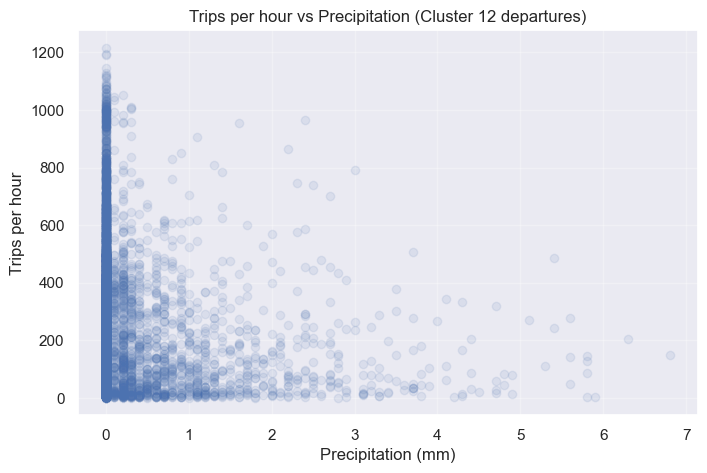

In [107]:
import matplotlib.pyplot as plt

sample = grouped_rf_weather[['trip_count', 'precipitation (mm)']].dropna()

plt.figure(figsize=(8,5))
plt.scatter(sample['precipitation (mm)'], sample['trip_count'], alpha=0.1)
plt.xlabel('Precipitation (mm)')
plt.ylabel('Trips per hour')
plt.title('Trips per hour vs Precipitation (Cluster 12 departures)')
plt.grid(alpha=0.3)
plt.show()


/var/folders/2q/0s6yfy4s7cdcl3184vyy5v_w0000gp/T/ipykernel_6513/3255532719.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_trips_by_prec = sample.groupby(prec_bin)['trip_count'].mean()


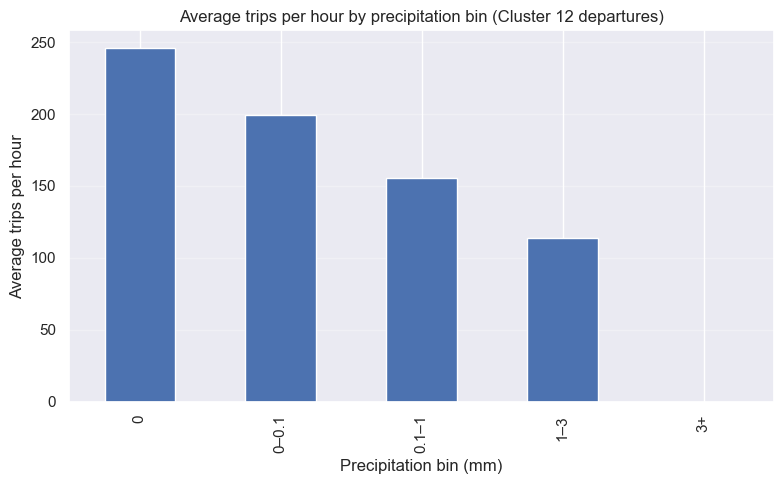

In [108]:
bins   = [0, 0.1, 1, 3, 10, 50]
labels = ['0', '0–0.1', '0.1–1', '1–3', '3+']

prec_bin = pd.cut(sample['precipitation (mm)'], bins=bins, labels=labels, include_lowest=True)
avg_trips_by_prec = sample.groupby(prec_bin)['trip_count'].mean()

plt.figure(figsize=(8,5))
avg_trips_by_prec.plot(kind='bar')
plt.xlabel('Precipitation bin (mm)')
plt.ylabel('Average trips per hour')
plt.title('Average trips per hour by precipitation bin (Cluster 12 departures)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Prepare Holidays as feature in X

In [109]:
holidays = pd.read_csv('holidays.csv')
# All dates and hours for 2018
dates = pd.date_range('2018-01-01', '2018-12-31', freq='D', name='date')
hours = pd.Index(range(24), name='hour')

all_date_hour_2018 = (
    pd.MultiIndex.from_product([dates, hours], names=['date', 'hour'])
      .to_frame(index=False)
)

# Optional: combined datetime and index
all_date_hour_2018['datetime'] = all_date_hour_2018['date'] + pd.to_timedelta(all_date_hour_2018['hour'], unit='h')
all_date_hour_2018.set_index('datetime', inplace=True)
len(all_date_hour_2018)

8760

In [110]:
month_name_to_number = {'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04', 'May': '05', 'Jun': '06',
                               'Jul': '07', 'Aug': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'}
holidays['Date'] = holidays['Date'].apply(lambda x: '2018-' + month_name_to_number[x[:3]] + '-' + x[4:].strip())
holidays['Date'] = pd.to_datetime(holidays['Date'], format='%Y-%m-%d')

holidays.set_index('Date', inplace=True)


In [111]:
holidays.drop(columns=['Day', 'Holiday Name', 'Comments'], inplace=True)

In [112]:
# One-hot encode Type on holidays without modifying the original dataframe
holidays_dummies = pd.get_dummies(holidays, columns=['Type'], prefix='type', dtype=int)
holidays_dummies.head()

,type_Federal Holiday,type_Government Holiday,type_Not A Public Holiday
Date,,,
2018-01-01,1,0,0
2018-01-15,1,0,0
2018-02-12,0,1,0
2018-02-19,1,0,0
2018-04-01,0,0,1


In [113]:
# Merge holidays_dummies with all_date_hour_2018
is_holiday = all_date_hour_2018.merge(
    holidays_dummies, 
    left_on='date', 
    right_index=True, 
    how='left'
)
len(is_holiday)

8760

In [114]:

# Fill NaN values with 0 for holiday type columns (non-holiday days)
holiday_cols = [col for col in is_holiday.columns if col.startswith('type_')]
is_holiday[holiday_cols] = is_holiday[holiday_cols].fillna(0).astype(int)

is_holiday.head()

,date,hour,type_Federal Holiday,type_Government Holiday,type_Not A Public Holiday
datetime,,,,,
2018-01-01 00:00:00,2018-01-01,0,1,0,0
2018-01-01 01:00:00,2018-01-01,1,1,0,0
2018-01-01 02:00:00,2018-01-01,2,1,0,0
2018-01-01 03:00:00,2018-01-01,3,1,0,0
2018-01-01 04:00:00,2018-01-01,4,1,0,0


In [115]:
is_holiday.drop(['date', 'hour'], axis=1, inplace=True)

In [116]:
is_holiday.iloc[358:365]

,type_Federal Holiday,type_Government Holiday,type_Not A Public Holiday
datetime,,,
2018-01-15 22:00:00,1,0,0
2018-01-15 23:00:00,1,0,0
2018-01-16 00:00:00,0,0,0
2018-01-16 01:00:00,0,0,0
2018-01-16 02:00:00,0,0,0
2018-01-16 03:00:00,0,0,0
2018-01-16 04:00:00,0,0,0


## Merge on the data set

In [117]:
# Merge holiday indicators on datetime index
grouped_rf_holiday = grouped_rf.merge(
    is_holiday,
    how='left',
    left_index=True,
    right_index=True
)
feature_cols = [
    c for c in grouped_rf_holiday.columns
    if c not in ['trip_count']
]

X_train_holiday = grouped_rf_holiday.loc[train_mask, feature_cols]
y_train      = grouped_rf_holiday.loc[train_mask, 'trip_count']

X_val_holiday   = grouped_rf_holiday.loc[val_mask, feature_cols]
y_val        = grouped_rf_holiday.loc[val_mask, 'trip_count']

X_test_holiday  = grouped_rf_holiday.loc[test_mask, feature_cols]
y_test       = grouped_rf_holiday.loc[test_mask, 'trip_count']

rf_holiday = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_holiday.fit(X_train_holiday, y_train)

y_train_pred_holiday = rf_holiday.predict(X_train_holiday)
y_val_pred_holiday   = rf_holiday.predict(X_val_holiday)
y_test_pred_holiday  = rf_holiday.predict(X_test_holiday)
print_stats(y_train, y_train_pred_holiday, "TRAIN – RF with holiday")
print_stats(y_val,   y_val_pred_holiday,   "VALIDATION – RF with holiday")
print_stats(y_test,  y_test_pred_holiday,  "TEST – RF with holiday")

TRAIN – RF with holiday:
	r^2   = 0.976683
	MAE   = 19.101420
	MAPE  = 20.170229
	MSE   = 1152.084996
VALIDATION – RF with holiday:
	r^2   = 0.923300
	MAE   = 38.903237
	MAPE  = 27.059706
	MSE   = 4514.940072
TEST – RF with holiday:
	r^2   = 0.727446
	MAE   = 55.965796
	MAPE  = 87.632627
	MSE   = 8811.561670


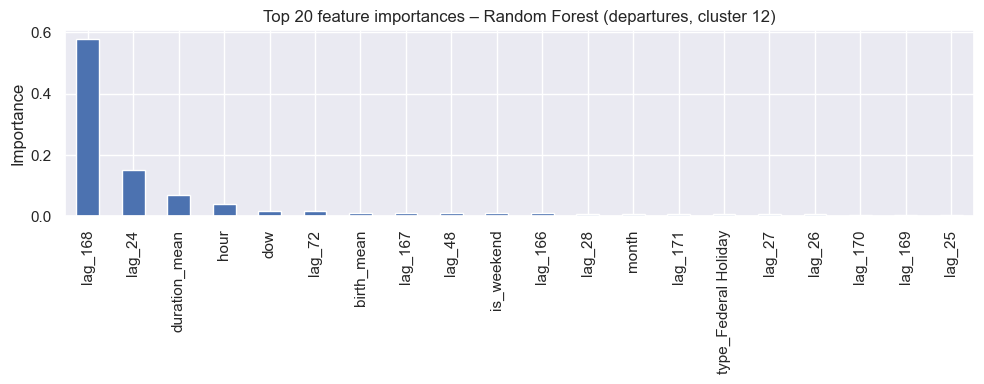

lag_24                  1.519897e-01
lag_48                  1.132495e-02
lag_72                  1.731529e-02
most_common_gender_1    3.841029e-08
dtype: float64


In [118]:
importances = pd.Series(rf_holiday.feature_importances_, index=feature_cols)
imp_top = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,4))
imp_top.plot(kind='bar')
plt.title("Top 20 feature importances – Random Forest (departures, cluster 12)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# If you want to see just the lags:
print(importances[['lag_24', 'lag_48', 'lag_72', 'most_common_gender_1']])

## With both weather and holiday

In [119]:
# Merge holiday indicators on datetime index
grouped_rf_h_w = grouped_rf_weather.merge(
    is_holiday,
    how='left',
    left_index=True,
    right_index=True
)
grouped_rf_h_w.columns

Index(['trip_count', 'is_weekend', 'duration_mean', 'birth_mean', 'lag_24',
       'lag_25', 'lag_26', 'lag_27', 'lag_28', 'lag_48', 'lag_72', 'lag_166',
       'lag_167', 'lag_168', 'lag_169', 'lag_170', 'lag_171', 'hour', 'dow',
       'month', 'most_common_user_type_Subscriber', 'most_common_gender_1',
       'most_common_gender_2', 'temperature_2m (°C)', 'precipitation (mm)',
       'rain (mm)', 'cloudcover (%)', 'cloudcover_low (%)',
       'cloudcover_mid (%)', 'cloudcover_high (%)', 'windspeed_10m (km/h)',
       'winddirection_10m (°)', 'type_Federal Holiday',
       'type_Government Holiday', 'type_Not A Public Holiday'],
      dtype='object')

In [120]:

feature_cols = [
    c for c in grouped_rf_h_w
.columns
    if c not in ['trip_count']
]

x_train_w_h = grouped_rf_h_w.loc[train_mask, feature_cols]
y_train      = grouped_rf_h_w.loc[train_mask, 'trip_count']

x_val_w_h   = grouped_rf_h_w.loc[val_mask, feature_cols]
y_val        = grouped_rf_h_w.loc[val_mask, 'trip_count']

x_test_w_h  = grouped_rf_h_w.loc[test_mask, feature_cols]
y_test       = grouped_rf_h_w.loc[test_mask, 'trip_count']

rf_w_h = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf_w_h.fit(x_train_w_h, y_train)

y_train_pred_holiday = rf_w_h.predict(x_train_w_h)
y_val_pred_holiday   = rf_w_h.predict(x_val_w_h)
y_test_pred_holiday  = rf_w_h.predict(x_test_w_h)
print_stats(y_train, y_train_pred_holiday, "TRAIN – RF with holiday and weather")
print_stats(y_val,   y_val_pred_holiday,   "VALIDATION – RF with holiday and weather")
print_stats(y_test,  y_test_pred_holiday,  "TEST – RF with holiday and weather")

TRAIN – RF with holiday and weather:
	r^2   = 0.981018
	MAE   = 17.341050
	MAPE  = 17.549805
	MSE   = 937.908664
VALIDATION – RF with holiday and weather:
	r^2   = 0.931184
	MAE   = 38.708275
	MAPE  = 26.558712
	MSE   = 4050.857096
TEST – RF with holiday and weather:
	r^2   = 0.759491
	MAE   = 52.724149
	MAPE  = 74.178242
	MSE   = 7775.545882


In [121]:
importances = pd.Series(rf_holiday.feature_importances_, index=feature_cols)
imp_top = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,4))
imp_top.plot(kind='bar')
plt.title("Top 20 feature importances – Random Forest (departures, cluster 12)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# If you want to see just the lags:
print(importances[['lag_24', 'lag_48', 'lag_72', 'type_Federal Holiday']])

ValueError: Length of values (25) does not match length of index (34)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(RandomForestRegressor(),
                                   param_grid, error_score='raise')
random_search.fit(x_train_w_h, y_train)
print(random_search.best_estimator_)

In [ ]:
rf_w_h = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf_w_h.fit(x_train_w_h, y_train)

y_train_pred_holiday = rf_w_h.predict(x_train_w_h)
y_val_pred_holiday   = rf_w_h.predict(x_val_w_h)
y_test_pred_holiday  = rf_w_h.predict(x_test_w_h)
print_stats(y_train, y_train_pred_holiday, "TRAIN – RF with holiday and weather")
print_stats(y_val,   y_val_pred_holiday,   "VALIDATION – RF with holiday and weather")
print_stats(y_test,  y_test_pred_holiday,  "TEST – RF with holiday and weather")

In [ ]:
holidays

In [ ]:
day_start, day_end = pd.Timestamp('2018-01-01'), pd.Timestamp('2018-01-15')
pd.date_range(start=day_start, end=day_end + pd.Timedelta('1D'), freq='h'),y_train[day_start : day_end + pd.Timedelta('1D')]

In [ ]:
plotprediction(
    y_train[day_start : day_end + pd.Timedelta('1D')],
    y_train_pred_holiday[(y_train.index >= day_start) & (y_train.index <= day_end + pd.Timedelta('1D'))],
    labels=['observed', 'RF prediction'], title=f"Random Forest Forecast with Holiday and Weather (Cluster 12 departures from {day_start.date()} to {day_end.date()})"
)

In [ ]:
y_test_pred_holiday

In [ ]:
pca = PCA(n_components=0.70)  # Retain 95% of variance
x_train_w_h_stds = (x_train_w_h - x_train_w_h.mean()) / x_train_w_h.std()
x_val_w_h_stds = (x_val_w_h - x_train_w_h.mean()) / x_train_w_h.std()
x_test_w_h_stds = (x_test_w_h - x_train_w_h.mean()) / x_train_w_h.std()
X_train_pca = pca.fit_transform(x_train_w_h_stds)
X_val_pca = pca.transform(x_val_w_h_stds)
X_test_pca = pca.transform(x_test_w_h_stds)

plt.plot(pca.explained_variance_ratio_.cumsum(), '-ob')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

In [ ]:
rf_w_h_pca = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_w_h_pca.fit(X_train_pca, y_train)
y_train_pred_pca = rf_w_h_pca.predict(X_train_pca)
y_val_pred_pca = rf_w_h_pca.predict(X_val_pca)
y_test_pred_pca  = rf_w_h_pca.predict(X_test_pca)
print_stats(y_train, y_train_pred_pca, "TRAIN – RF with holiday, weather and PCA")
print_stats(y_val,  y_val_pred_pca,  "VAL – RF with holiday, weather and PCA")
print_stats(y_test,  y_test_pred_pca,  "TEST – RF with holiday, weather and PCA")